In [2]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.0 MB/s eta 0:00:00


In [3]:
import kagglehub
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import category_encoders as ce
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler, MinMaxScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, roc_auc_score, mean_squared_error, r2_score, confusion_matrix
from sklearn.base import BaseEstimator, TransformerMixin
from xgboost import XGBClassifier
from IPython.display import display

In [4]:
# Download and load dataset
path = kagglehub.dataset_download("dhairyajeetsingh/ecommerce-customer-behavior-dataset")
csv_path = os.path.join(path, "ecommerce_customer_churn_dataset.csv")

df = pd.read_csv(csv_path)
print('Dataframe created successfully')
display(df.head())

100%|██████████| 1.96M/1.96M [00:00<00:00, 46.9MB/s]

Extracting files...


Dataframe created successfully


,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [ ]:
#Observing the 5 first rows...
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [ ]:
#and 5 last rows
df.tail()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
49995,38.0,Female,USA,Los Angeles,10.0,10.0,35.8,8.8,51.2,3.0,...,9.2,5.0,1.0,20.7,25.2,1.0,2365.98,3499.0,0,Q2
49996,37.0,Male,USA,Chicago,1.4,21.0,32.4,9.6,32.5,2.0,...,17.6,5.0,3.0,38.6,12.1,4.0,1293.60,3154.0,0,Q3
49997,44.0,Female,USA,Phoenix,2.8,19.0,40.3,10.4,50.6,1.0,...,25.2,4.0,6.0,59.9,NaN,1.0,1655.28,1622.0,0,Q1
49998,41.0,Female,USA,Chicago,2.9,17.0,29.9,10.1,60.8,1.0,...,34.6,5.0,2.0,NaN,14.1,3.0,1286.11,2634.0,0,Q2
49999,56.0,Male,UK,Leeds,2.2,2.0,18.2,NaN,46.0,0.0,...,0.0,7.0,0.0,0.0,4.2,1.0,1072.61,612.0,0,Q3


In [ ]:
df.shape  #Getting the shape...

(50000, 25)

In [ ]:
df.columns   #And columns (or categories) of the dataset

Index(['Age', 'Gender', 'Country', 'City', 'Membership_Years',
       'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session',
       'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases',
       'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned', 'Signup_Quarter'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

In [ ]:
df.isnull().sum()

,0
Age,2495
Gender,0
Country,0
City,0
Membership_Years,0
Login_Frequency,0
Session_Duration_Avg,3399
Pages_Per_Session,3000
Cart_Abandonment_Rate,0
Wishlist_Items,4000


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,47505.0,37.802968,11.834668,5.00,29.0000,38.000,46.00,200.000000
Membership_Years,50000.0,2.984009,2.059105,0.10,1.4000,2.500,4.00,10.000000
Login_Frequency,50000.0,11.624660,7.810657,0.00,6.0000,11.000,17.00,46.000000
Session_Duration_Avg,46601.0,27.660754,10.871013,1.00,19.7000,26.800,34.70,75.600000
Pages_Per_Session,47000.0,8.737811,3.778220,1.00,6.0000,8.400,11.20,24.100000
Cart_Abandonment_Rate,50000.0,57.079973,16.282723,0.00,46.4000,58.100,68.70,143.743350
Wishlist_Items,46000.0,4.298391,3.189754,0.00,2.0000,4.000,6.00,28.000000
Total_Purchases,50000.0,13.111576,7.017312,-13.00,8.0000,12.000,17.00,128.700000
Average_Order_Value,50000.0,123.117330,175.569714,26.38,87.0500,112.970,144.44,9666.379178
Days_Since_Last_Purchase,47000.0,29.792872,29.695062,0.00,9.0000,21.000,41.00,287.000000


Churned
0    35550
1    14450
Name: count, dtype: int64


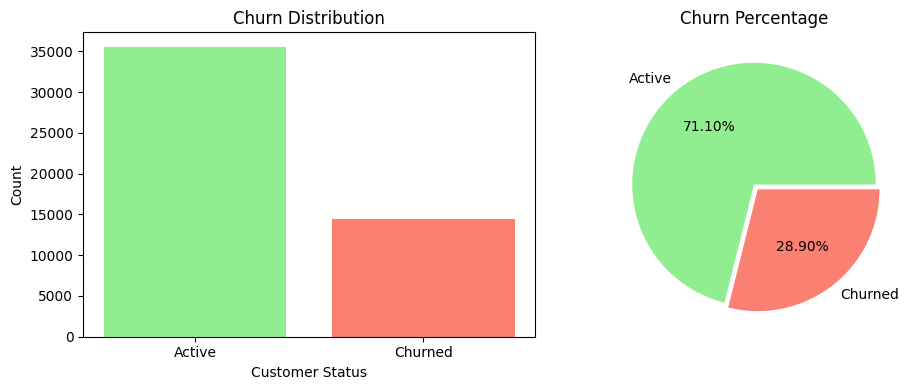

In [ ]:
import matplotlib.pyplot as plt

# Đếm số lượng khách hàng Ở lại (0) và Rời bỏ (1)
vc = df['Churned'].value_counts().sort_index()

print(vc)

labels = ['Active', 'Churned']
colors = ['#90EE90', '#FA8072']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(vc.index, vc.values, color=colors)
axes[0].set_xticks(vc.index)
axes[0].set_xticklabels(labels)
axes[0].set_xlabel("Customer Status")
axes[0].set_ylabel("Count")
axes[0].set_title("Churn Distribution")

# Vẽ biểu đồ Tròn (Pie Chart) ở bên phải
axes[1].pie(
    vc.values,
    explode=[0, 0.05],
    labels=labels,
    autopct='%1.2f%%',
    colors=colors,
    startangle=0
)
axes[1].set_title("Churn Percentage")

# Hiển thị
plt.tight_layout()
plt.show()

In [6]:
X = df.drop(columns=['Churned'])
y = df['Churned']
print("X and y have been separated.")

X and y have been separated.


In [ ]:
def plot_numerical(X, col_name):
    """Plots histogram, boxplot and displays summary statistics for numerical features."""
    if col_name not in X.columns:
        return

    stats = X[col_name].describe().to_frame().T
    stats['Missing_Count'] = X[col_name].isnull().sum()
    stats['Missing_Ratio (%)'] = round((stats['Missing_Count'] / len(X)) * 100, 2)
    display(stats)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(data=X, x=col_name, kde=True, color="#1f77b4", ax=axes[0])
    sns.boxplot(data=X, x=col_name, color="#1f77b4", ax=axes[1])
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_numerical_with_churn_rate(X, y, feature_name, log_scale=False, bins=50):
    """
    Hàm vẽ biểu đồ kết hợp: Histogram phân bố + Đường Churn Rate
    Nhóm Missing (NaN) được xử lý như một cột giá trị bình thường ở cuối trục X.
    """
    if feature_name not in X.columns:
        print(f"Lỗi: Không tìm thấy cột '{feature_name}' trong dữ liệu X!")
        return

    print(f"--- Đang phân tích biến: {feature_name} ---")

    # Tạo DataFrame tạm từ X và y
    target_col = y.name if hasattr(y, 'name') and y.name else 'Churned'
    temp_df = pd.concat([X[feature_name], y], axis=1)
    temp_df.columns = [feature_name, target_col]

    # 1. TÍNH TOÁN DỮ LIỆU MISSING
    missing_mask = temp_df[feature_name].isna()
    missing_count = missing_mask.sum()
    missing_churn_rate = np.nan
    if missing_count > 0:
        missing_churn_rate = temp_df[missing_mask][target_col].mean() * 100

    # 2. LỌC DỮ LIỆU ĐỂ VẼ
    plot_df = temp_df[[feature_name, target_col]].dropna().copy()

    if log_scale:
        min_val = plot_df[feature_name].min()
        if min_val < 0:
            plot_df[feature_name] = np.log1p(plot_df[feature_name] - min_val)
        else:
            plot_df[feature_name] = np.log1p(plot_df[feature_name])

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # TÍNH TOÁN BINS VÀ CHURN RATE
    bin_edges = np.histogram_bin_edges(plot_df[feature_name], bins=bins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    plot_df['bin'] = pd.cut(plot_df[feature_name], bins=bin_edges, include_lowest=True)
    churn_rate = plot_df.groupby('bin', observed=False)[target_col].mean() * 100

    # VẼ BIỂU ĐỒ HISTOGRAM (TRỤC Y CHÍNH)
    sns.histplot(
        data=plot_df, x=feature_name, kde=False, bins=bin_edges,
        color="#1f77b4", alpha=0.5, stat="count", ax=ax1
    )
    ax1.set_title(f'Distribution & Churn Rate: {feature_name}', fontsize=14, fontweight='bold')
    ax1.set_xlabel(feature_name, fontsize=12)
    ax1.set_ylabel('Count', fontsize=12)
    ax1.grid(axis='y', linestyle='--', alpha=0.3)

    ax2 = ax1.twinx()

    # Chuẩn bị tọa độ cho đường Line (gom cả nhóm khuyết vào nếu có)
    x_points = list(bin_centers)
    y_points = list(churn_rate.values)

    # 3. VẼ CỘT MISSING NHƯ MỘT BIẾN BÌNH THƯỜNG
    if missing_count > 0:
        gap = (bin_edges[-1] - bin_edges[0]) / bins
        x_missing = bin_edges[-1] + gap * 2

        ax1.set_xlim(bin_edges[0] - gap, x_missing + gap * 1.5)

        # Vẽ cột Missing
        ax1.bar(x_missing, missing_count, width=gap, color='#1f77b4', alpha=0.5)

        # Thêm nhãn "NaN" ở trục X
        y_min, y_max = ax1.get_ylim()
        ax1.text(x_missing, y_min - (y_max * 0.05), 'NaN', ha='center', va='top', fontsize=10)

        # Đưa dữ liệu Missing vào đường Line đỏ
        if not pd.isna(missing_churn_rate):
            x_points.append(x_missing)
            y_points.append(missing_churn_rate)

    # Vẽ toàn bộ đường Line đỏ
    ax2.plot(x_points, y_points, color='red', marker='o', linewidth=2, label='Churn Rate (%)')
    ax2.set_ylabel('Churn Rate (%)', fontsize=12, color='red')

    # Căn chỉnh giới hạn trục Y phụ
    max_rate = max(y_points) if len(y_points) > 0 and not pd.isna(max(y_points)) else 15
    ax2.set_ylim(0, max_rate + (max_rate * 0.2) + 1)

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

    plt.tight_layout()
    plt.show()

In [11]:
def plot_categorical_with_churn_rate(X, y, feature_name, sort_by_value=False):
    """
    Hàm vẽ biểu đồ cho biến phân loại (Categorical) hoặc số rời rạc.
    Đã cập nhật để nhận X và y riêng biệt.
    """
    if feature_name not in X.columns:
        print(f"Lỗi: Không tìm thấy cột '{feature_name}' trong dữ liệu X!")
        return

    # Tạo DataFrame tạm từ X và y
    target_col = y.name if hasattr(y, 'name') and y.name else 'Churned'
    temp_df = pd.concat([X[feature_name], y], axis=1)
    temp_df.columns = [feature_name, target_col]

    # Lọc bỏ các dòng mà target bị thiếu
    temp_df.dropna(subset=[target_col], inplace=True)

    # Tính toán thông số Missing
    total_rows = len(temp_df)
    missing_count = temp_df[feature_name].isna().sum()
    missing_ratio = (missing_count / total_rows) * 100
    has_missing = missing_count > 0

    print(f"--- Đang phân tích biến: {feature_name} ---")
    print(f"Tổng số dòng: {total_rows}")
    print(f"Dữ liệu khuyết: {missing_count} dòng ({missing_ratio:.2f}%)")
    print("-" * 50)

    if has_missing:
        temp_df[feature_name] = temp_df[feature_name].fillna('NaN')

    # TÍNH TOÁN BẢNG THỐNG KÊ
    summary = temp_df.groupby(feature_name).agg(
        Count=(target_col, 'size'),
        Churn_Rate=(target_col, lambda x: x.mean() * 100)
    ).reset_index()

    # LOGIC SẮP XẾP
    if has_missing:
        missing_row = summary[summary[feature_name] == 'NaN']
        valid_rows = summary[summary[feature_name] != 'NaN'].copy()

        if sort_by_value:
            valid_rows['sort_key'] = pd.to_numeric(valid_rows[feature_name], errors='ignore')
            valid_rows = valid_rows.sort_values('sort_key', ascending=True).drop(columns=['sort_key'])
        else:
            valid_rows = valid_rows.sort_values('Count', ascending=False)

        summary = pd.concat([valid_rows, missing_row]).reset_index(drop=True)
    else:
        if sort_by_value:
            summary['sort_key'] = pd.to_numeric(summary[feature_name], errors='ignore')
            summary = summary.sort_values('sort_key', ascending=True).drop(columns=['sort_key']).reset_index(drop=True)
        else:
            summary = summary.sort_values('Count', ascending=False).reset_index(drop=True)

    summary['% of Total'] = (summary['Count'] / total_rows * 100).round(2)

    # VẼ BIỂU ĐỒ
    fig, ax1 = plt.subplots(figsize=(12, 6))
    sns.barplot(data=summary, x=feature_name, y='Count', color="#1f77b4", alpha=0.7, ax=ax1)
    ax1.set_title(f'Distribution & Churn Rate by: {feature_name}', fontsize=14, fontweight='bold')
    ax1.set_xlabel(feature_name, fontsize=12)
    ax1.set_ylabel('Count', fontsize=12)
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(axis='y', linestyle='--', alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(range(len(summary)), summary['Churn_Rate'], color='red', marker='o', linewidth=2, label='Churn Rate (%)')
    ax2.set_ylabel('Churn Rate (%)', fontsize=12, color='red')

    max_rate = summary['Churn_Rate'].max()
    ax2.set_ylim(0, max_rate + (max_rate * 0.2) + 1 if not pd.isna(max_rate) else 15)
    ax2.legend(loc='upper right')

    plt.tight_layout()
    plt.show()
    print(summary[[feature_name, 'Count', '% of Total', 'Churn_Rate']].to_string(index=False))

# 1. EDA

## Ma trận tương quan

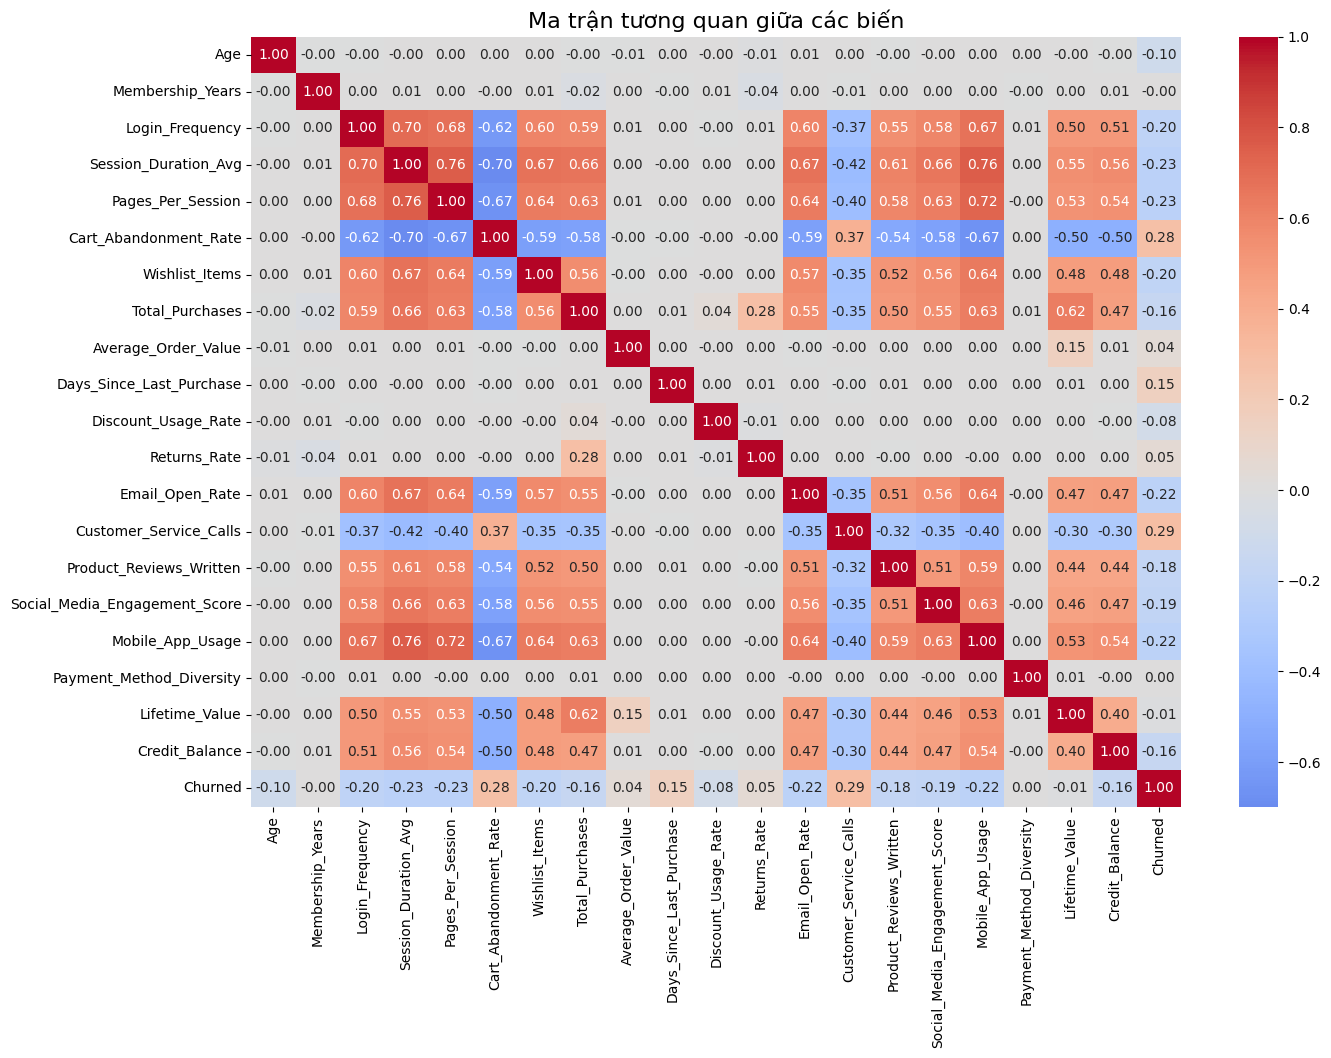

Độ tương quan của các biến với Churned:
Churned                          1.000000
Customer_Service_Calls           0.291103
Cart_Abandonment_Rate            0.277963
Days_Since_Last_Purchase         0.153360
Returns_Rate                     0.054189
Average_Order_Value              0.042288
Payment_Method_Diversity         0.004524
Membership_Years                -0.000623
Lifetime_Value                  -0.010684
Discount_Usage_Rate             -0.077121
Age                             -0.102849
Credit_Balance                  -0.156921
Total_Purchases                 -0.160029
Product_Reviews_Written         -0.181225
Social_Media_Engagement_Score   -0.191792
Wishlist_Items                  -0.197708
Login_Frequency                 -0.204379
Email_Open_Rate                 -0.222213
Mobile_App_Usage                -0.222876
Session_Duration_Avg            -0.228010
Pages_Per_Session               -0.231799
Name: Churned, dtype: float64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Tính toán ma trận tương quan cho các biến số
# Lưu ý: Chỉ lấy các cột numeric để tránh lỗi
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

# Vẽ Heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Ma trận tương quan giữa các biến', fontsize=16)
plt.show()

# Hiển thị độ tương quan riêng với biến Churned
print("Độ tương quan của các biến với Churned:")
print(corr_matrix['Churned'].sort_values(ascending=False))

## Phân tích biến Number

,count,mean,std,min,25%,50%,75%,max,Missing_Count,Missing_Ratio (%)
Age,47505.0,37.802968,11.834668,5.0,29.0,38.0,46.0,200.0,2495,4.99


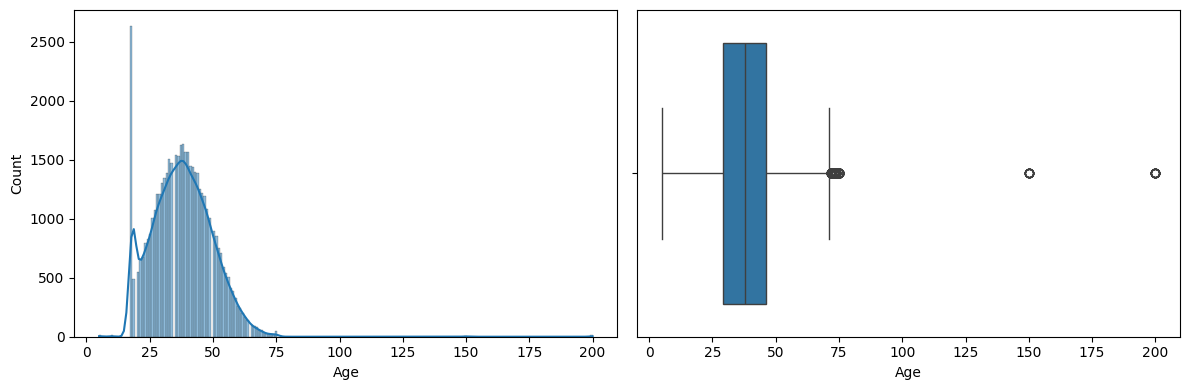

In [ ]:
# Age
plot_numerical(X, 'Age')

--- Đang phân tích biến: Age ---


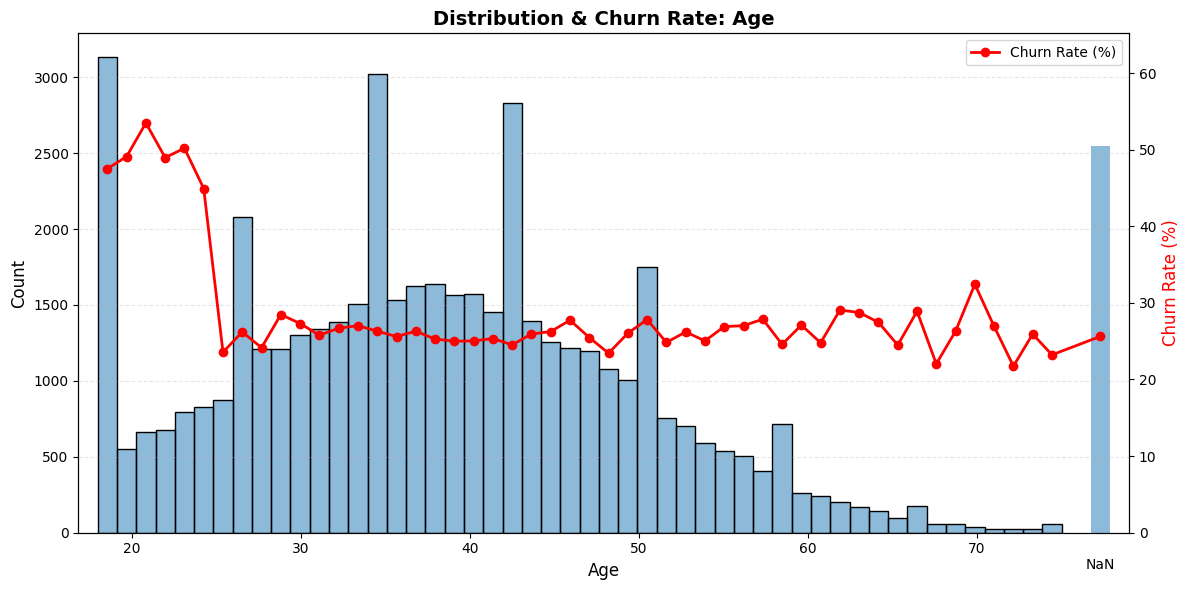

In [ ]:
age_outliers = X[(X['Age'] < 18) | (X['Age'] > 100)]
X.drop(age_outliers.index, inplace=True)

plot_numerical_with_churn_rate(X, y, 'Age')

,count,mean,std,min,25%,50%,75%,max,Missing_Count,Missing_Ratio (%)
Membership_Years,49950.0,2.984048,2.059045,0.1,1.4,2.5,4.0,10.0,0,0.0


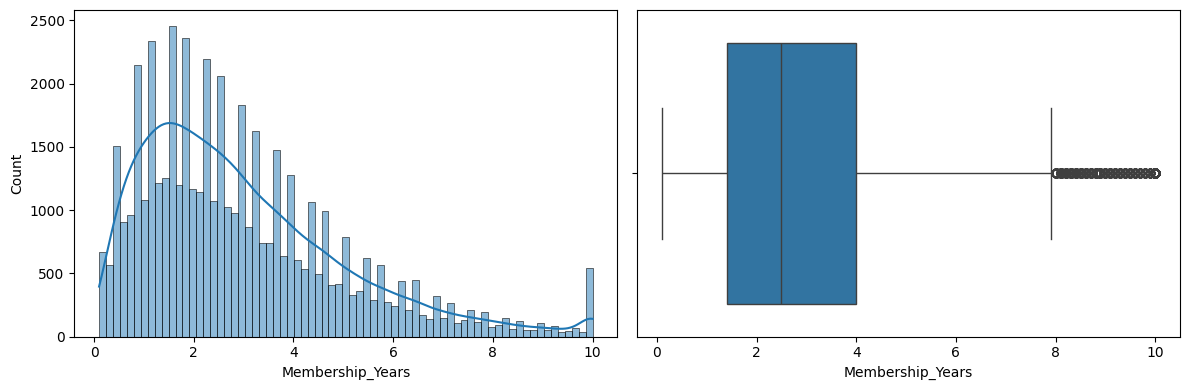

In [ ]:
# Membership_Years
plot_numerical(X, 'Membership_Years')

--- Đang phân tích biến: Membership_Years ---


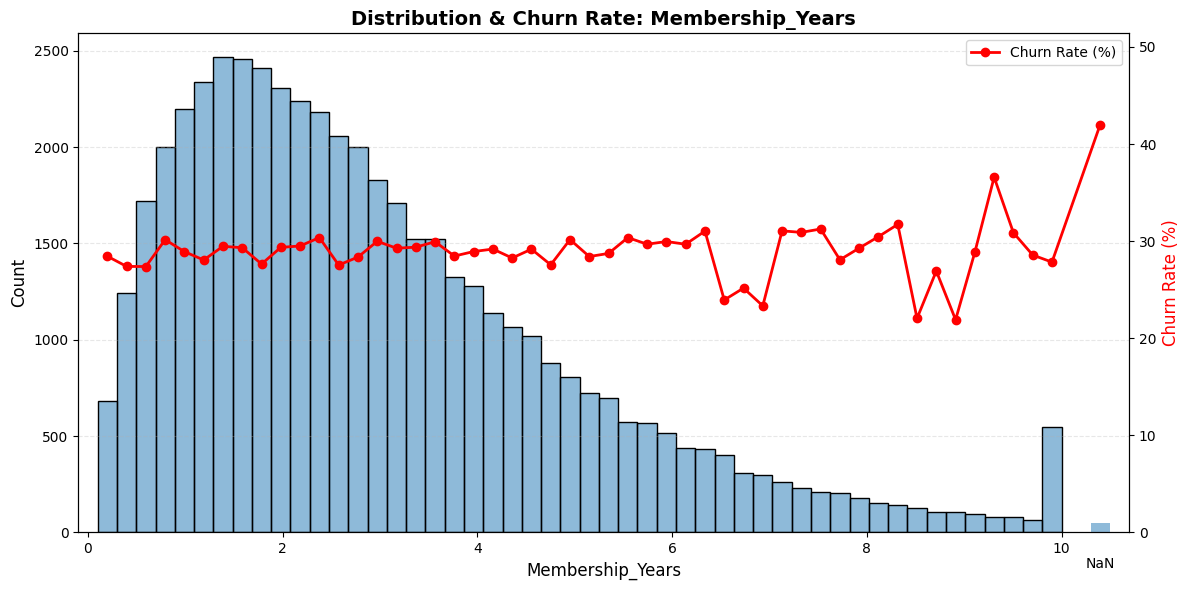

In [ ]:
plot_numerical_with_churn_rate(X, y, 'Membership_Years')

,count,mean,std,min,25%,50%,75%,max,Missing_Count,Missing_Ratio (%)
Login_Frequency,49950.0,11.625686,7.810739,0.0,6.0,11.0,17.0,46.0,0,0.0


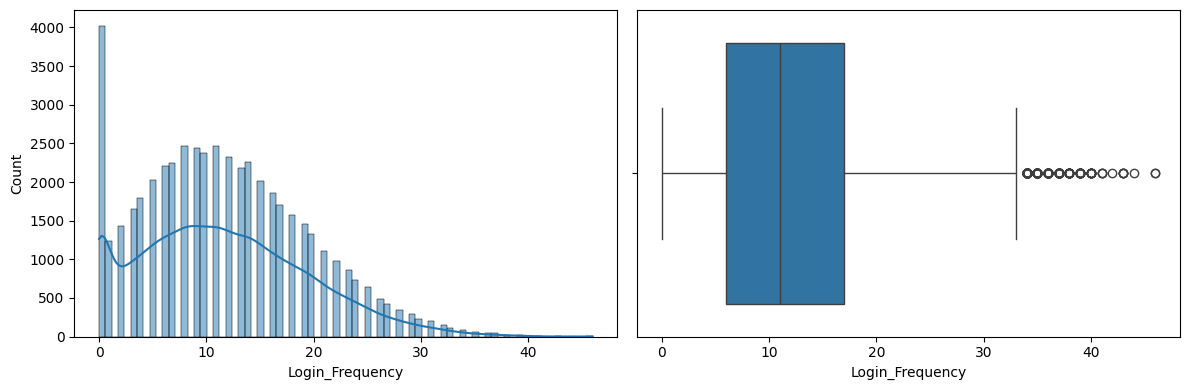

In [ ]:
# Login_Frequency
plot_numerical(X, 'Login_Frequency')

--- Đang phân tích biến: Login_Frequency ---


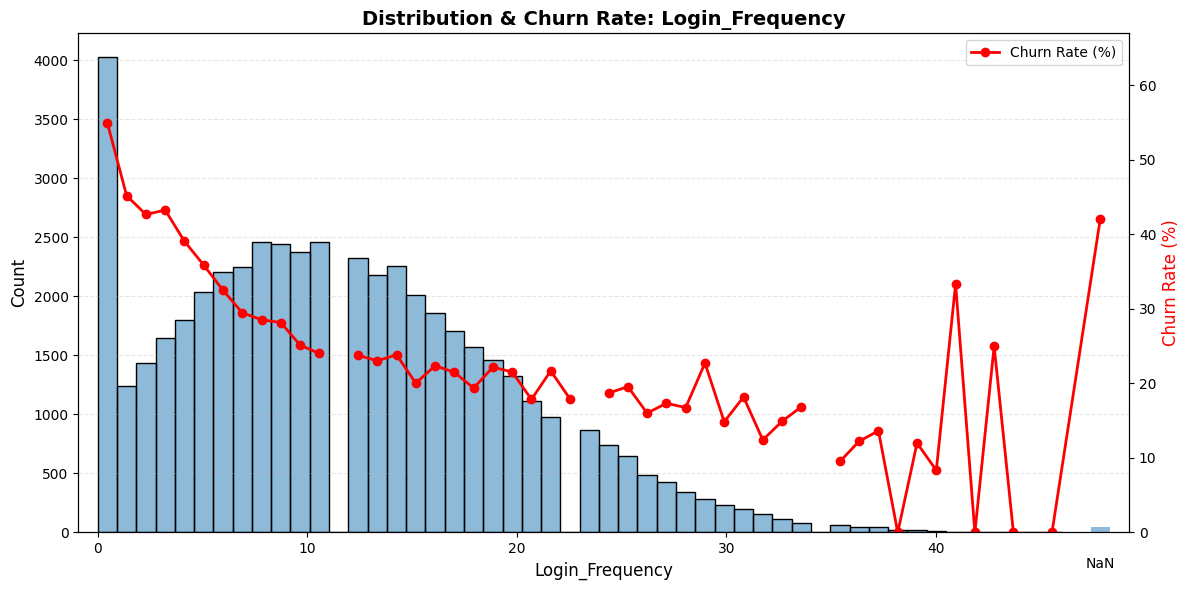

In [ ]:
plot_numerical_with_churn_rate(X, y, 'Login_Frequency')

,count,mean,std,min,25%,50%,75%,max,Missing_Count,Missing_Ratio (%)
Session_Duration_Avg,46557.0,27.660756,10.870068,1.0,19.7,26.8,34.7,75.6,3393,6.79


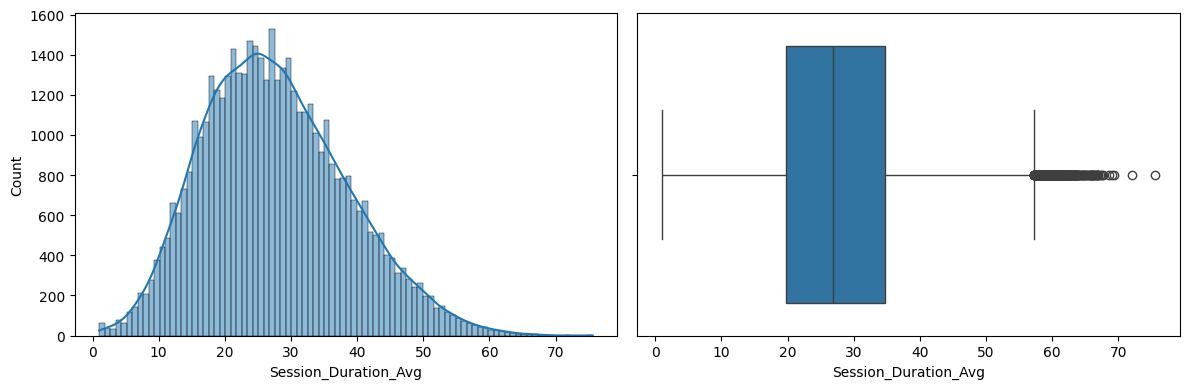

In [ ]:
# Session_Duration_Avg
plot_numerical(X, 'Session_Duration_Avg')

--- Đang phân tích biến: Session_Duration_Avg ---


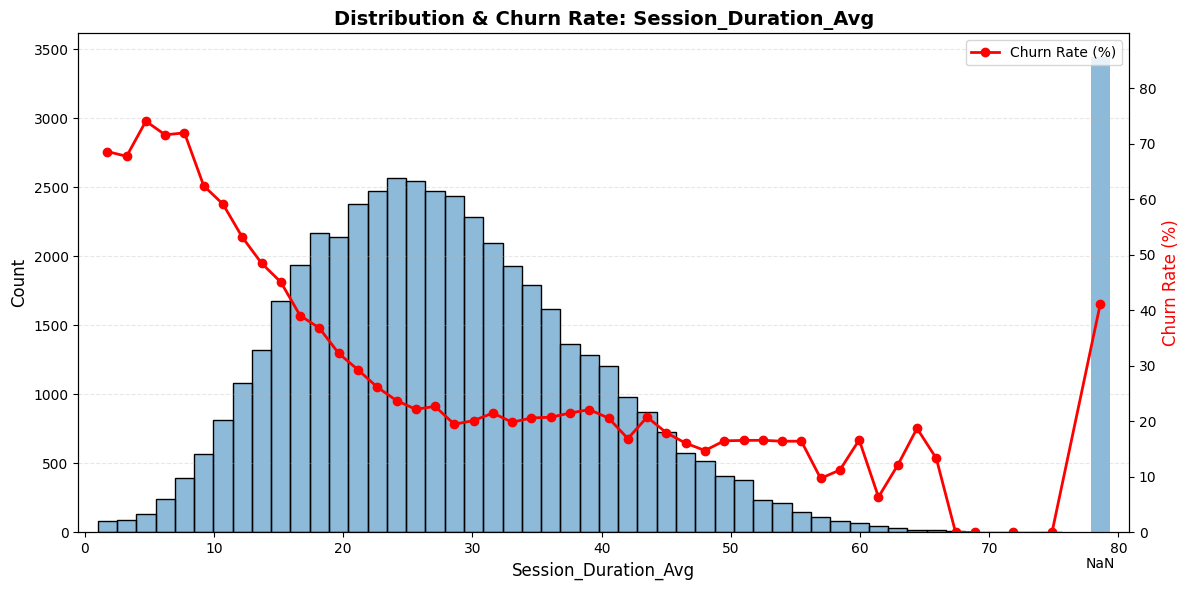

In [ ]:
plot_numerical_with_churn_rate(X, y, 'Session_Duration_Avg')

,count,mean,std,min,25%,50%,75%,max,Missing_Count,Missing_Ratio (%)
Pages_Per_Session,47000.0,8.737811,3.77822,1.0,6.0,8.4,11.2,24.1,3000,6.0


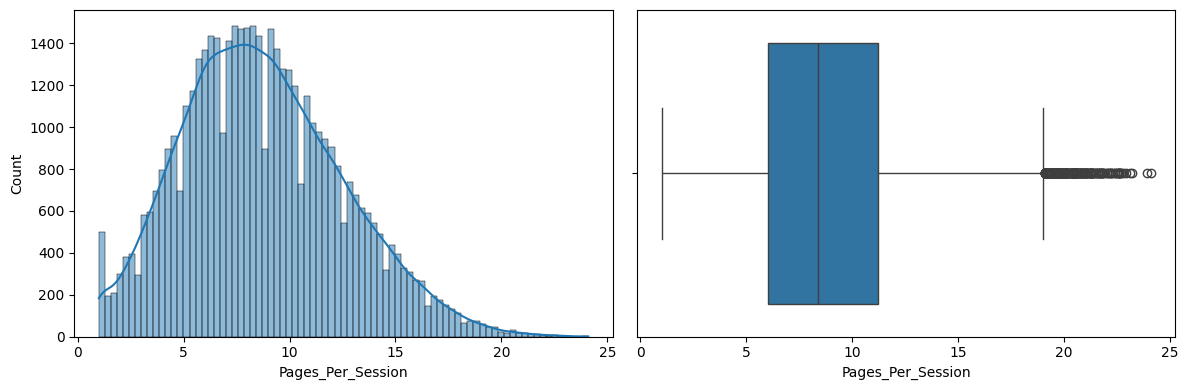

In [ ]:
plot_numerical(df, 'Pages_Per_Session')

--- Đang phân tích biến: Pages_Per_Session ---


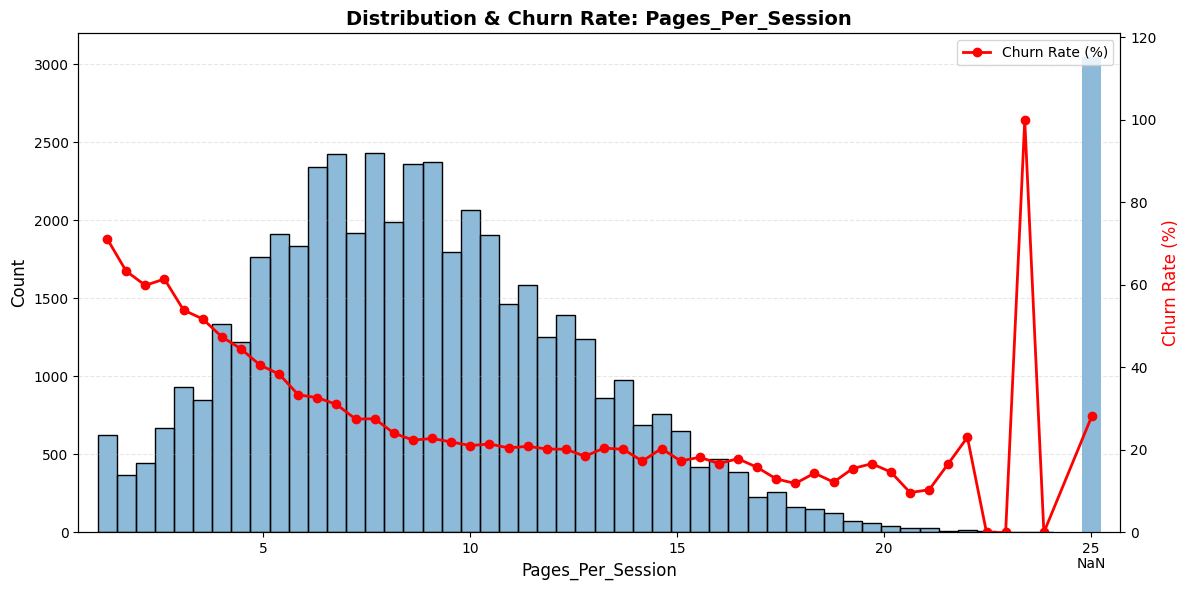

In [ ]:
plot_numerical_with_churn_rate(X, y, 'Pages_Per_Session')

,count,mean,std,min,25%,50%,75%,max,Missing_Count,Missing_Ratio (%)
Cart_Abandonment_Rate,50000.0,57.079973,16.282723,0.0,46.4,58.1,68.7,143.74335,0,0.0


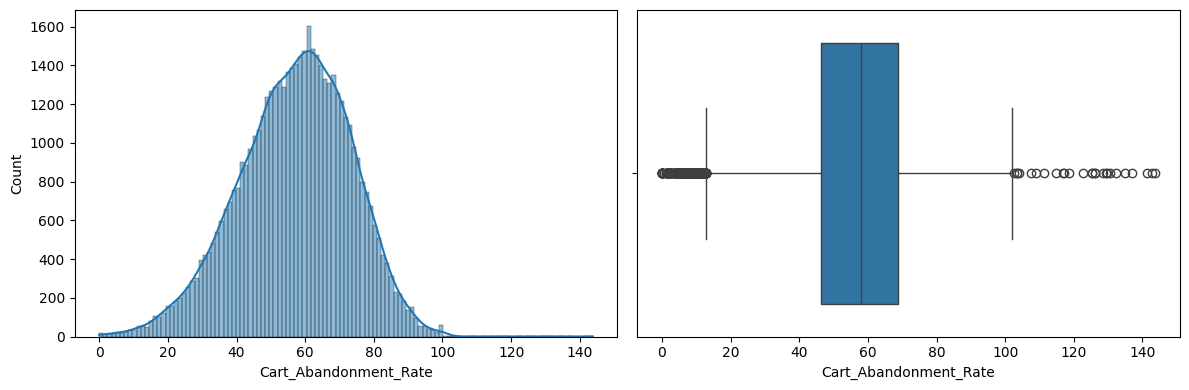

In [ ]:
# Cart_Abandonment_Rate
plot_numerical(df, 'Cart_Abandonment_Rate')

--- Đang phân tích biến: Cart_Abandonment_Rate ---


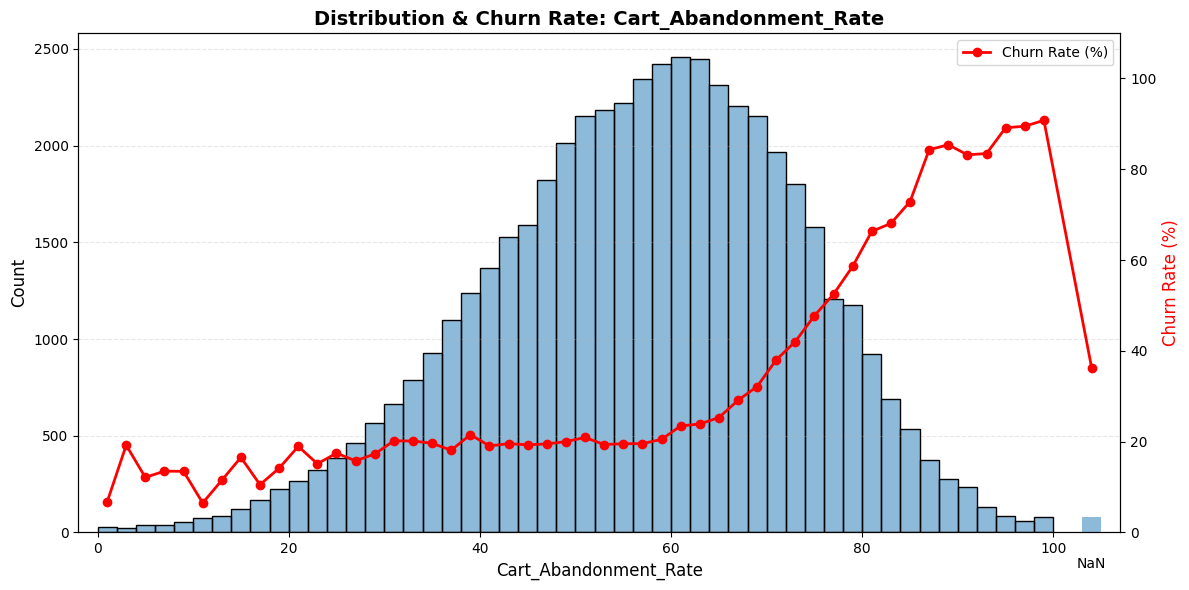

In [ ]:
X = X.drop(X[X['Cart_Abandonment_Rate'] > 100].index)
plot_numerical_with_churn_rate(X, y, 'Cart_Abandonment_Rate')

,count,mean,std,min,25%,50%,75%,max,Missing_Count,Missing_Ratio (%)
Wishlist_Items,46000.0,4.298391,3.189754,0.0,2.0,4.0,6.0,28.0,4000,8.0


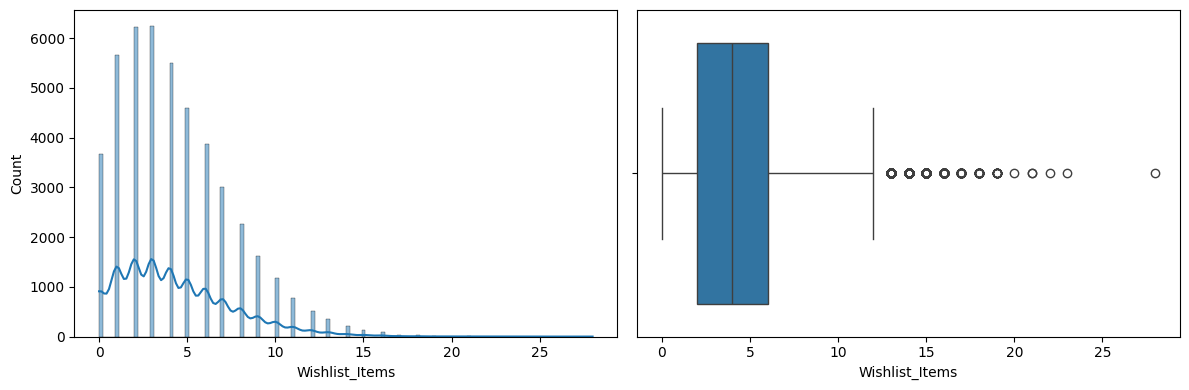

In [ ]:
# Wishlist_Items
plot_numerical(df, 'Wishlist_Items')

,count,mean,std,min,25%,50%,75%,max,Missing_Count,Missing_Ratio (%)
Total_Purchases,50000.0,13.111576,7.017312,-13.0,8.0,12.0,17.0,128.7,0,0.0


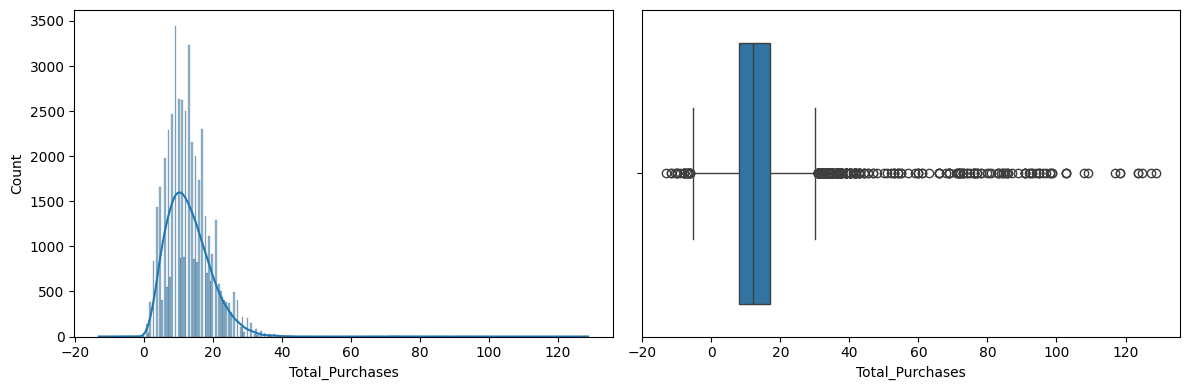

In [ ]:
# Total_Purchases
plot_numerical(df, 'Total_Purchases')

--- Đang phân tích biến: Total_Purchases ---


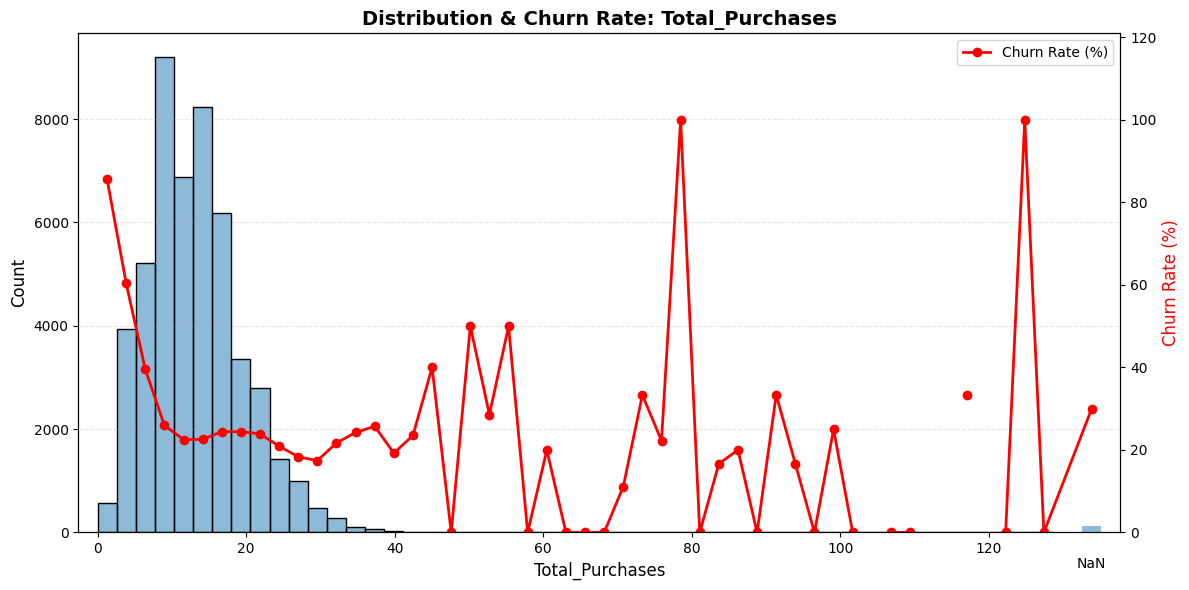

In [ ]:
X = X.drop(X[X['Total_Purchases'] < 0].index)
plot_numerical_with_churn_rate(X, y, 'Total_Purchases')

,count,mean,std,min,25%,50%,75%,max,Missing_Count,Missing_Ratio (%)
Average_Order_Value,50000.0,123.11733,175.569714,26.38,87.05,112.97,144.44,9666.379178,0,0.0


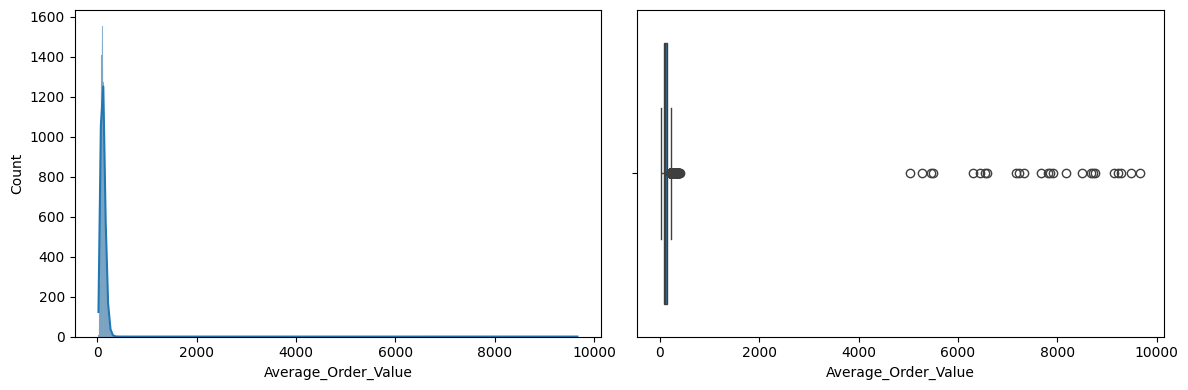

In [ ]:
# Average_Order_Value
plot_numerical(df, 'Average_Order_Value')

--- Đang phân tích biến: Average_Order_Value ---


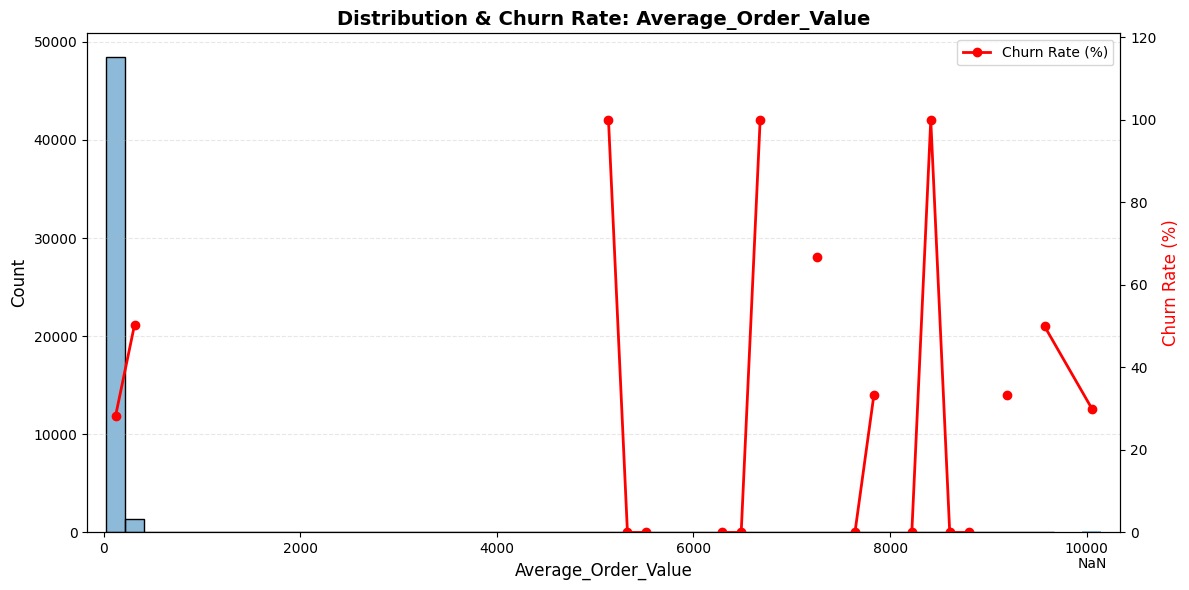

In [ ]:
plot_numerical_with_churn_rate(X, y, 'Average_Order_Value')

,count,mean,std,min,25%,50%,75%,max,Missing_Count,Missing_Ratio (%)
Days_Since_Last_Purchase,46885.0,29.802879,29.704573,0.0,9.0,21.0,41.0,287.0,2995,6.0


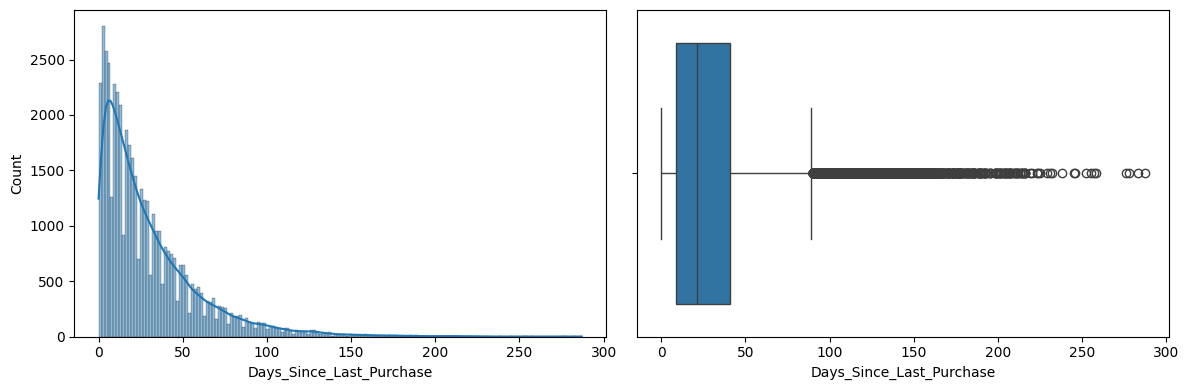

--- Đang phân tích biến: Days_Since_Last_Purchase ---


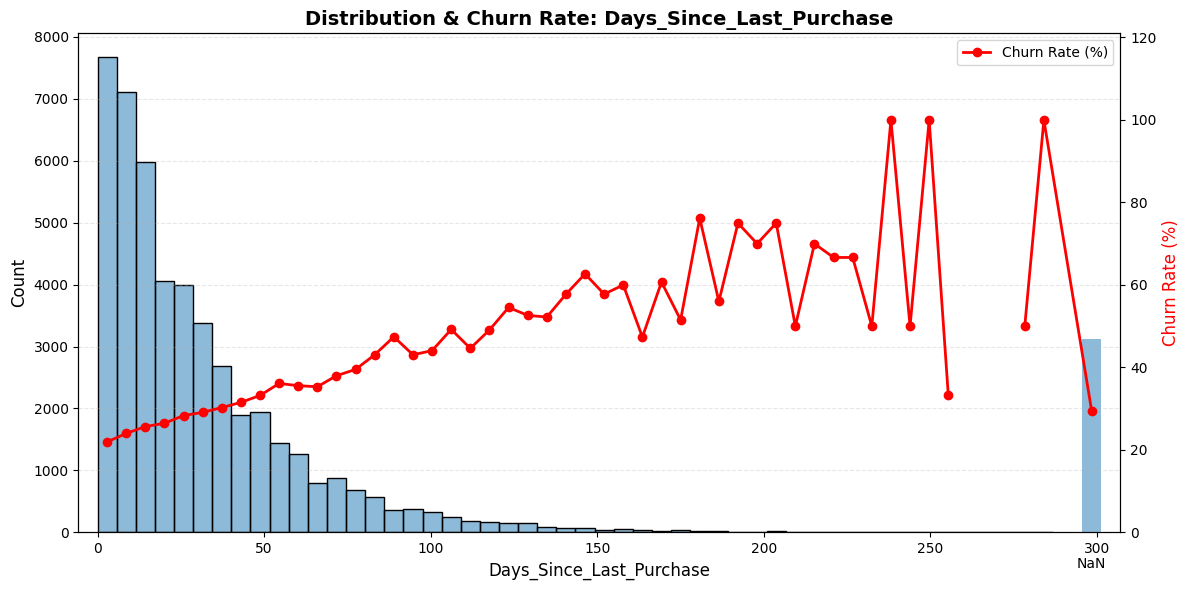

In [ ]:
plot_numerical(X, 'Days_Since_Last_Purchase')
plot_numerical_with_churn_rate(X, y, 'Days_Since_Last_Purchase')

,count,mean,std,min,25%,50%,75%,max,Missing_Count,Missing_Ratio (%)
Discount_Usage_Rate,46500.0,41.997485,21.373642,0.24,25.3,40.2,57.0,116.64,3500,7.0


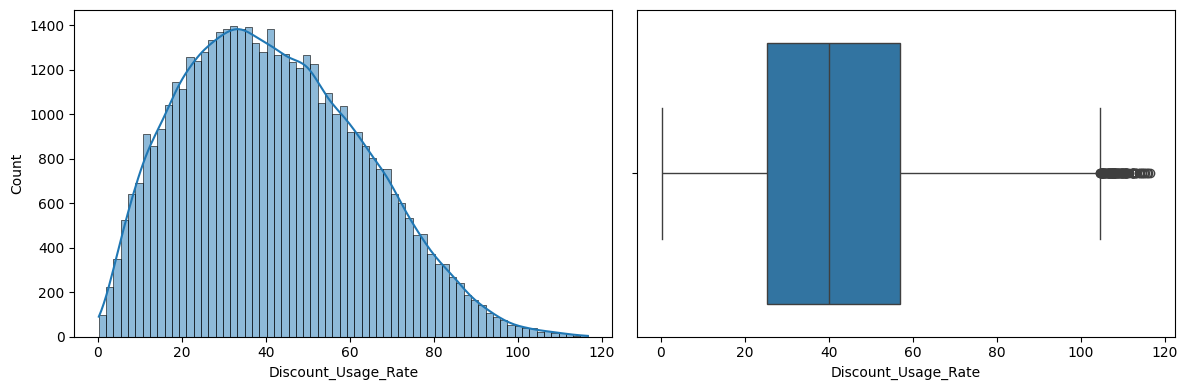

In [ ]:
# Discount_Usage_Rate
plot_numerical(df, 'Discount_Usage_Rate')

--- Đang phân tích biến: Discount_Usage_Rate ---


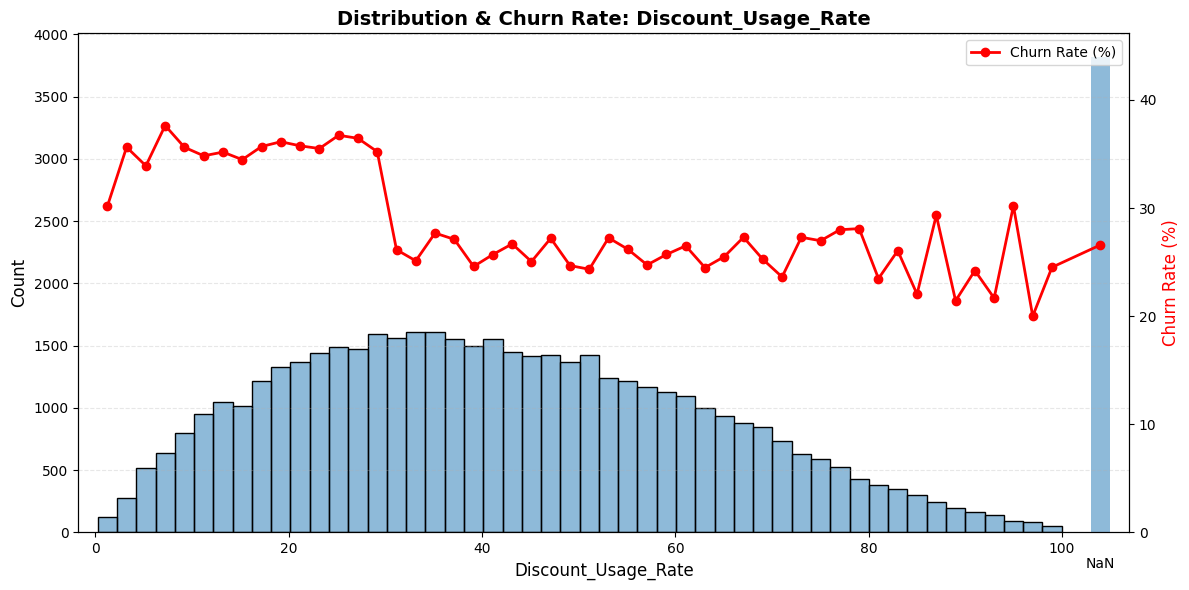

In [ ]:
X = X.drop(X[X['Discount_Usage_Rate'] > 100].index)
plot_numerical_with_churn_rate(X, y, 'Discount_Usage_Rate')

,count,mean,std,min,25%,50%,75%,max,Missing_Count,Missing_Ratio (%)
Returns_Rate,45217.0,6.681039,6.152803,0.0,2.9,5.4,9.1,99.615734,4457,8.97


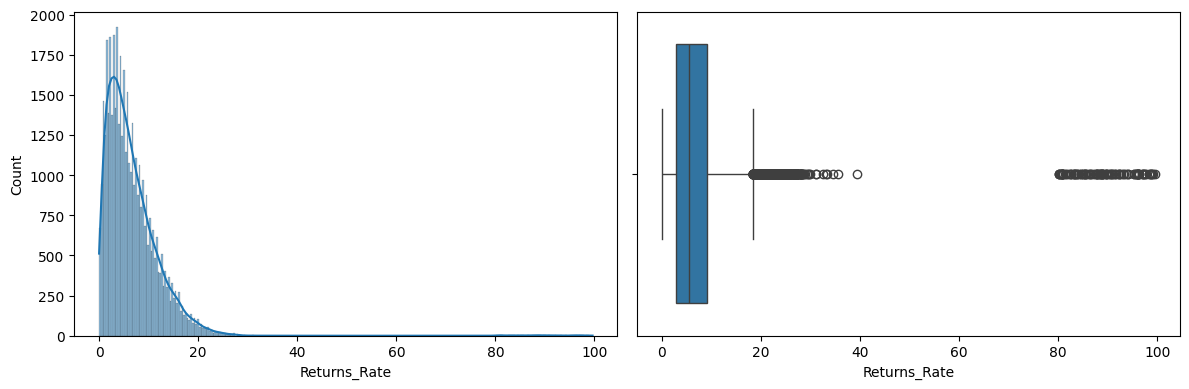

--- Đang phân tích biến: Returns_Rate ---


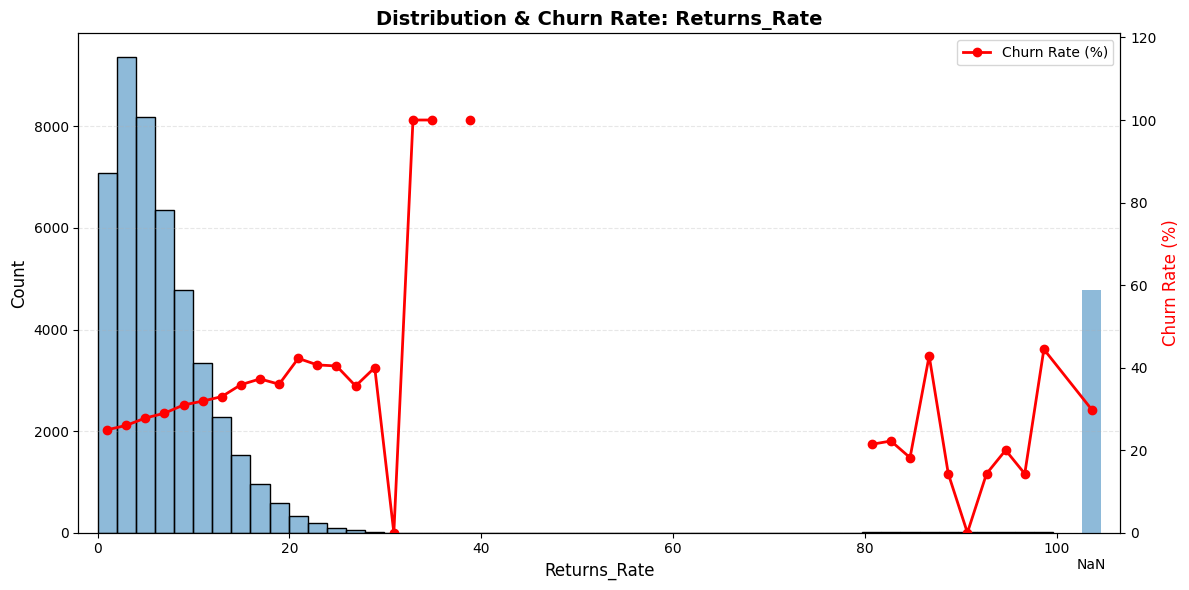

In [ ]:
plot_numerical(X, 'Returns_Rate')
plot_numerical_with_churn_rate(X, y, 'Returns_Rate')

,count,mean,std,min,25%,50%,75%,max,Missing_Count,Missing_Ratio (%)
Email_Open_Rate,47472.0,20.93798,14.252561,0.0,9.9,19.7,30.4,91.7,2528,5.06


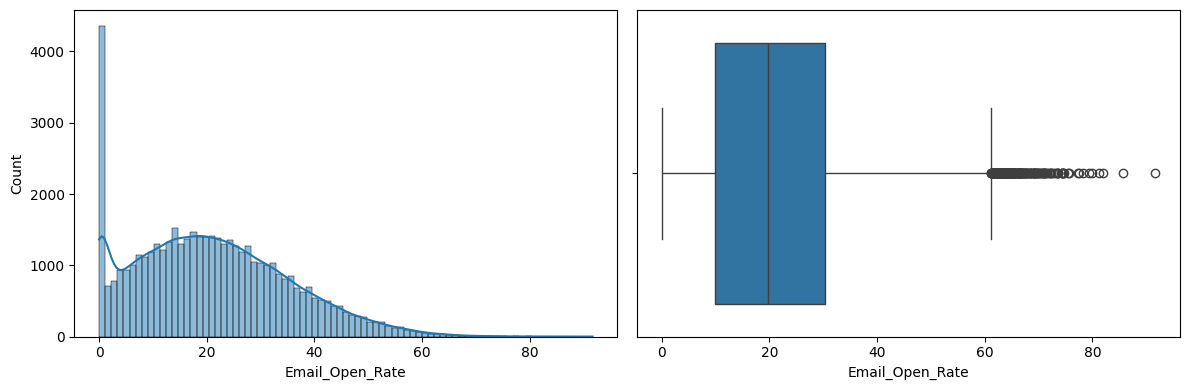

In [ ]:
# Email_Open_Rate
plot_numerical(df, 'Email_Open_Rate')

--- Đang phân tích biến: Email_Open_Rate ---


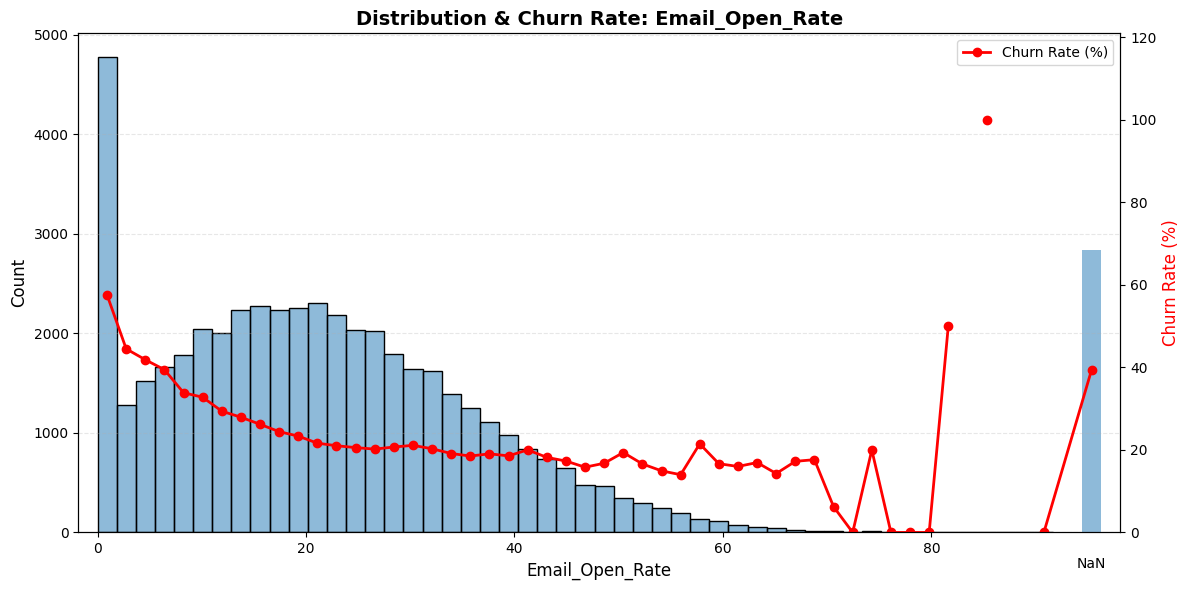

In [ ]:
plot_numerical_with_churn_rate(X, y, 'Email_Open_Rate')

,count,mean,std,min,25%,50%,75%,max,Missing_Count,Missing_Ratio (%)
Customer_Service_Calls,49832.0,5.681831,2.676052,0.0,4.0,5.0,7.0,21.0,168,0.34


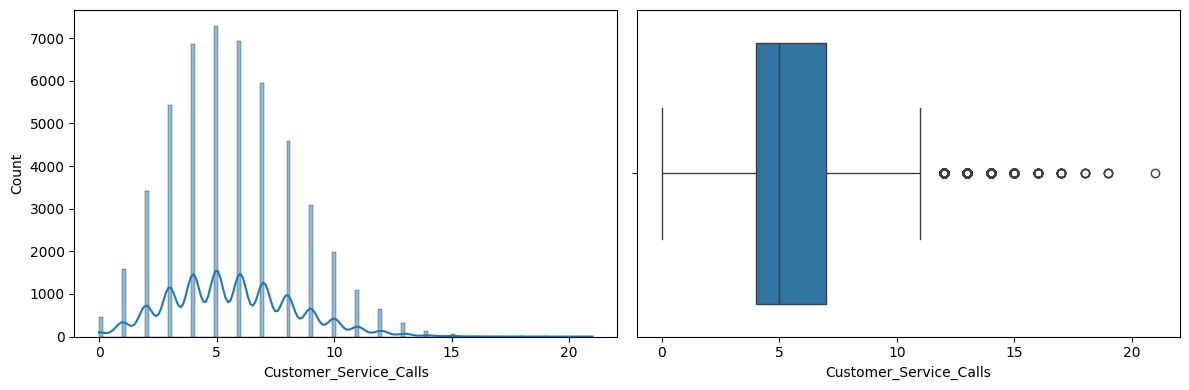

In [ ]:
# Customer_Service_Calls
plot_numerical(df, 'Customer_Service_Calls')

--- Đang phân tích biến: Customer_Service_Calls ---
Tổng số dòng: 50000
Dữ liệu khuyết: 491 dòng (0.98%)
--------------------------------------------------


/tmp/ipykernel_18354/1352766781.py:44: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  valid_rows['sort_key'] = pd.to_numeric(valid_rows[feature_name], errors='ignore')


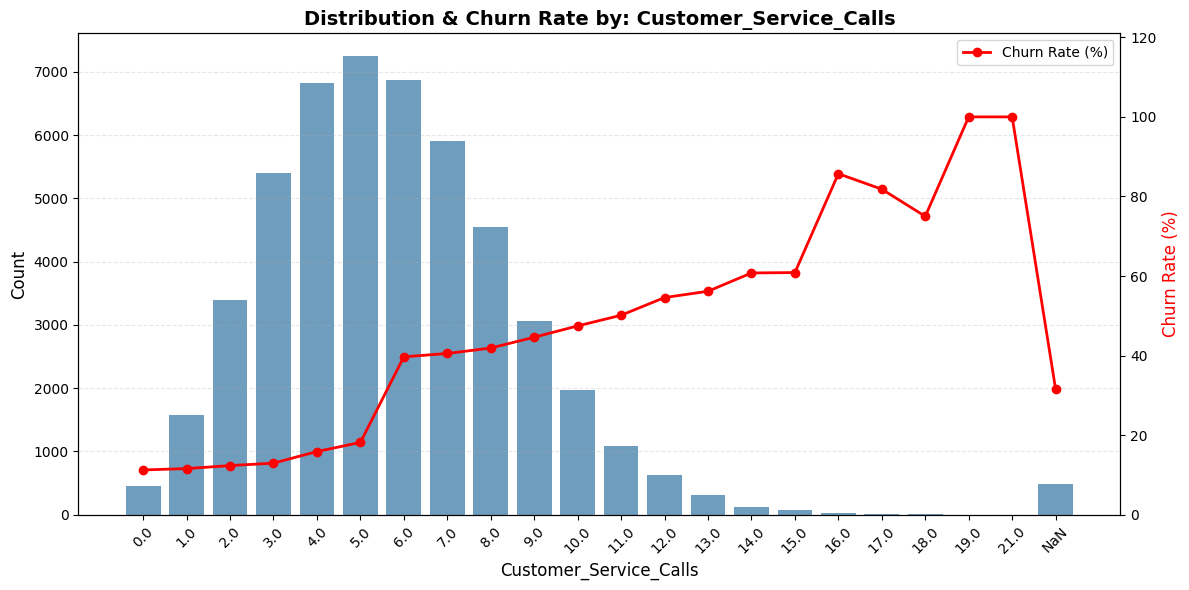

Customer_Service_Calls  Count  % of Total  Churn_Rate
                   0.0    453        0.91   11.258278
                   1.0   1569        3.14   11.599745
                   2.0   3402        6.80   12.345679
                   3.0   5398       10.80   12.967766
                   4.0   6827       13.65   15.878131
                   5.0   7247       14.49   18.173037
                   6.0   6870       13.74   39.694323
                   7.0   5907       11.81   40.528187
                   8.0   4549        9.10   41.899319
                   9.0   3057        6.11   44.618907
                  10.0   1968        3.94   47.459350
                  11.0   1083        2.17   50.138504
                  12.0    632        1.26   54.588608
                  13.0    308        0.62   56.168831
                  14.0    130        0.26   60.769231
                  15.0     69        0.14   60.869565
                  16.0     21        0.04   85.714286
                  17.0     1

In [ ]:
plot_categorical_with_churn_rate(X, y, 'Customer_Service_Calls', sort_by_value = True)

,count,mean,std,min,25%,50%,75%,max,Missing_Count,Missing_Ratio (%)
Product_Reviews_Written,46195.0,2.853491,2.329414,0.0,1.0,2.0,4.0,21.0,3479,7.0


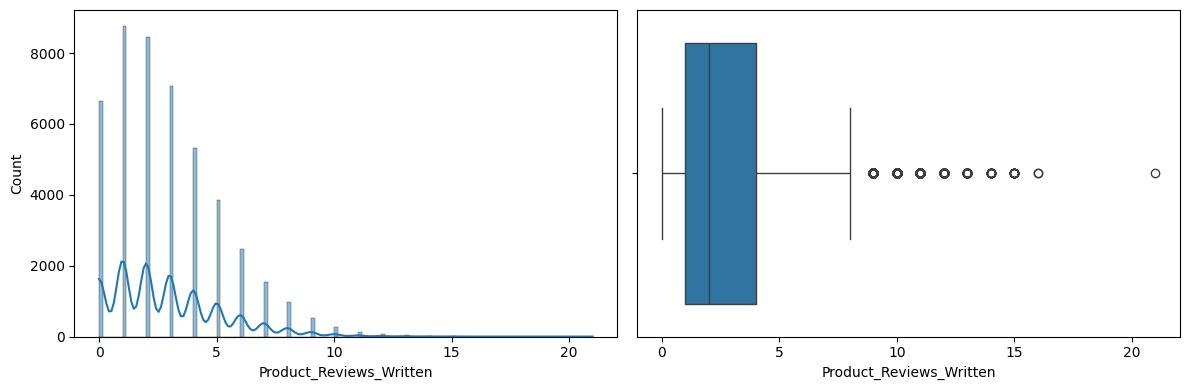

In [ ]:
# Product_Reviews_Written
plot_numerical(X, 'Product_Reviews_Written')

--- Đang phân tích biến: Product_Reviews_Written ---
Tổng số dòng: 50000
Dữ liệu khuyết: 3805 dòng (7.61%)
--------------------------------------------------


/tmp/ipykernel_18354/1352766781.py:44: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  valid_rows['sort_key'] = pd.to_numeric(valid_rows[feature_name], errors='ignore')


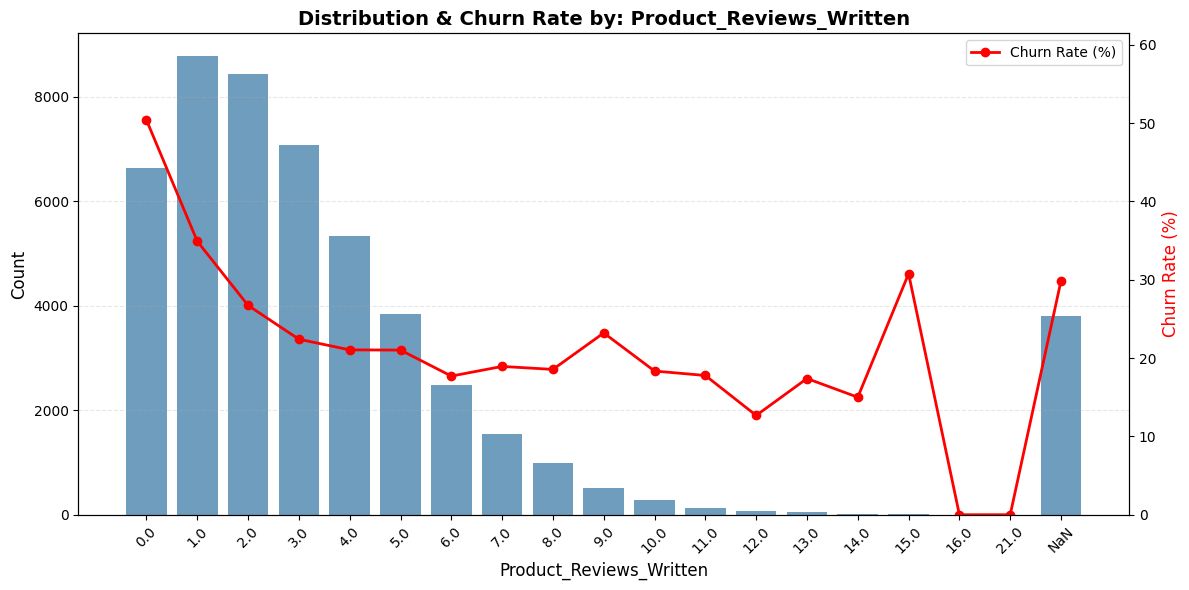

Product_Reviews_Written  Count  % of Total  Churn_Rate
                    0.0   6643       13.29   50.383863
                    1.0   8775       17.55   34.905983
                    2.0   8443       16.89   26.720360
                    3.0   7083       14.17   22.405760
                    4.0   5326       10.65   21.047691
                    5.0   3844        7.69   21.019771
                    6.0   2480        4.96   17.701613
                    7.0   1537        3.07   18.932986
                    8.0    981        1.96   18.552497
                    9.0    517        1.03   23.210832
                   10.0    278        0.56   18.345324
                   11.0    135        0.27   17.777778
                   12.0     71        0.14   12.676056
                   13.0     46        0.09   17.391304
                   14.0     20        0.04   15.000000
                   15.0     13        0.03   30.769231
                   16.0      2        0.00    0.000000
          

In [ ]:
plot_categorical_with_churn_rate(X, y, 'Product_Reviews_Written', sort_by_value = True)

,count,mean,std,min,25%,50%,75%,max,Missing_Count,Missing_Ratio (%)
Social_Media_Engagement_Score,43722.0,29.371735,20.582416,0.0,13.2,27.6,43.1,100.0,5952,11.98


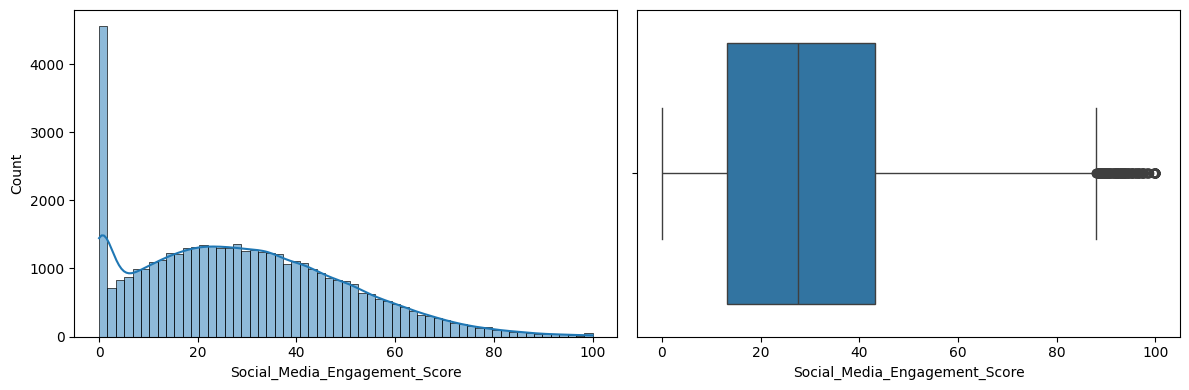

In [ ]:
# Social_Media_Engagement_Score
plot_numerical(X, 'Social_Media_Engagement_Score')

--- Đang phân tích biến: Social_Media_Engagement_Score ---


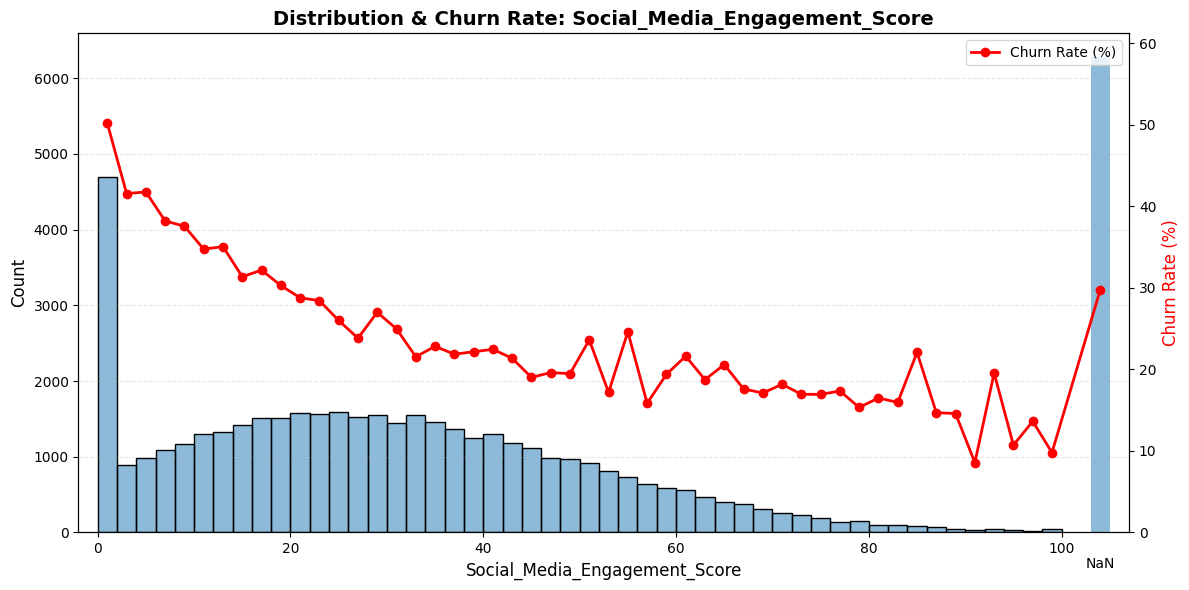

In [ ]:
plot_numerical_with_churn_rate(X, y, 'Social_Media_Engagement_Score')

,count,mean,std,min,25%,50%,75%,max,Missing_Count,Missing_Ratio (%)
Mobile_App_Usage,44705.0,19.371021,9.420637,0.0,12.5,18.6,25.5,61.9,4969,10.0


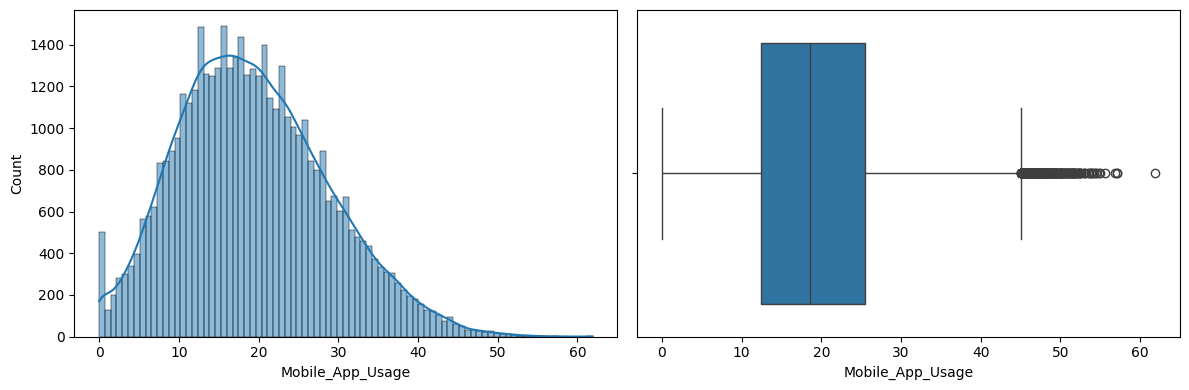

In [ ]:
# Mobile_App_Usage
plot_numerical(X, 'Mobile_App_Usage')

--- Đang phân tích biến: Mobile_App_Usage ---


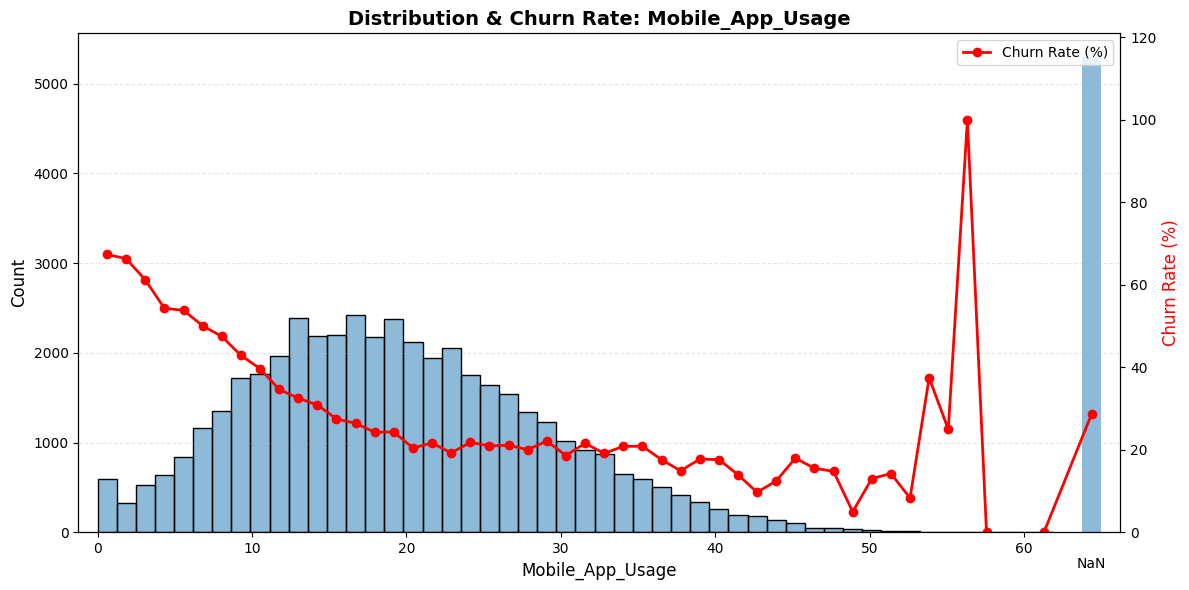

In [ ]:
plot_numerical_with_churn_rate(X, y, 'Mobile_App_Usage')

,count,mean,std,min,25%,50%,75%,max,Missing_Count,Missing_Ratio (%)
Payment_Method_Diversity,47181.0,2.35349,1.109943,1.0,2.0,2.0,3.0,5.0,2493,5.02


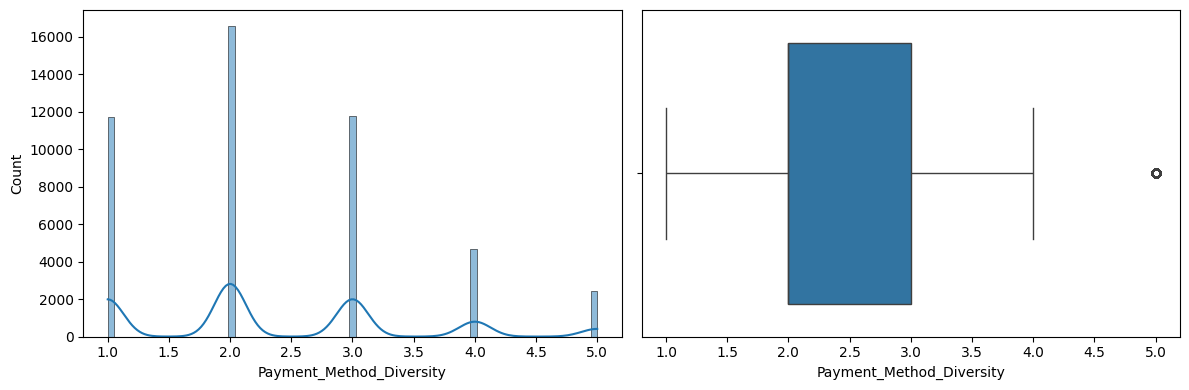

In [ ]:
plot_numerical(X,  'Payment_Method_Diversity')

--- Đang phân tích biến: Payment_Method_Diversity ---
Tổng số dòng: 50000
Dữ liệu khuyết: 2819 dòng (5.64%)
--------------------------------------------------


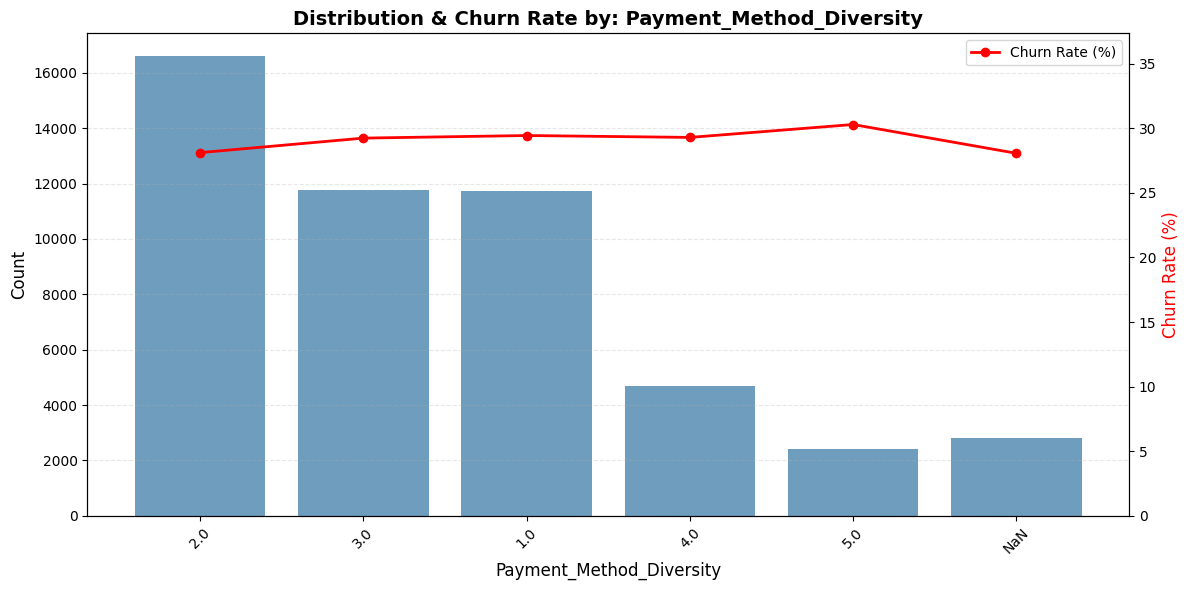

Payment_Method_Diversity  Count  % of Total  Churn_Rate
                     2.0  16594       33.19   28.112571
                     3.0  11756       23.51   29.236135
                     1.0  11720       23.44   29.436860
                     4.0   4691        9.38   29.290130
                     5.0   2420        4.84   30.289256
                     NaN   2819        5.64   28.059596


In [ ]:
plot_categorical_with_churn_rate(X, y, 'Payment_Method_Diversity')

,count,mean,std,min,25%,50%,75%,max,Missing_Count,Missing_Ratio (%)
Lifetime_Value,49674.0,1440.154063,906.975622,0.0,789.3325,1242.945,1873.9025,8987.24,0,0.0


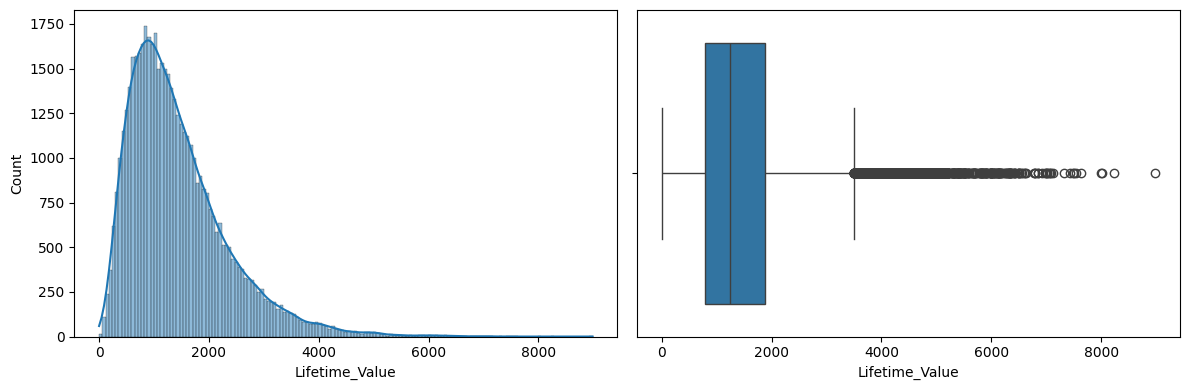

In [ ]:
# Lifetime_Value
plot_numerical(X, 'Lifetime_Value')

--- Đang phân tích biến: Lifetime_Value ---


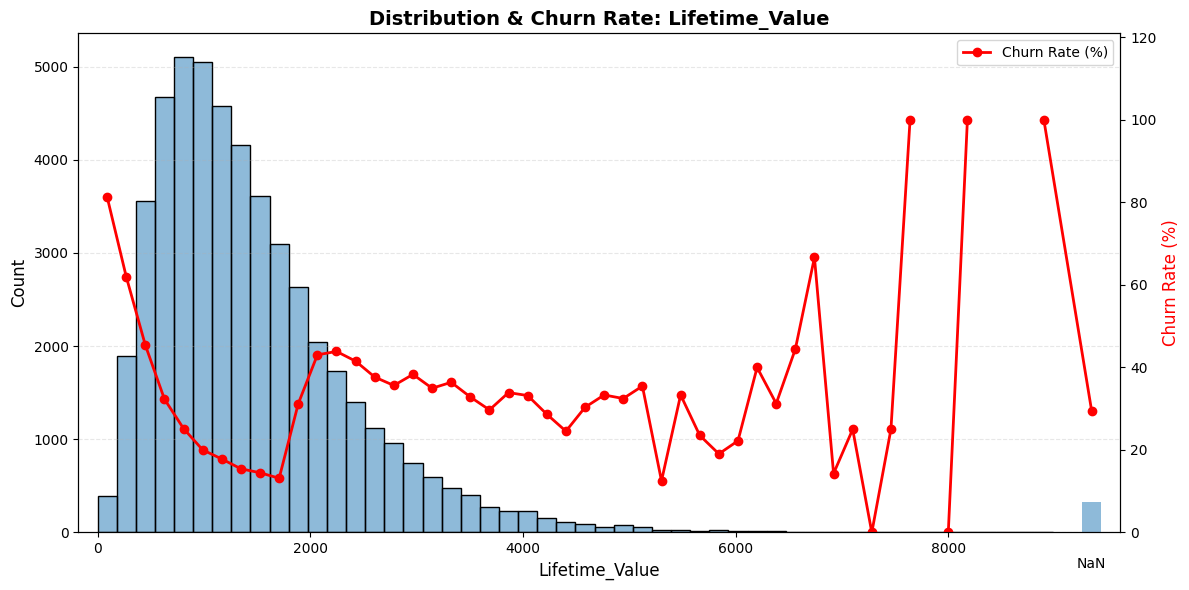

In [ ]:
plot_numerical_with_churn_rate(X, y, 'Lifetime_Value')

,count,mean,std,min,25%,50%,75%,max,Missing_Count,Missing_Ratio (%)
Credit_Balance,44215.0,1966.480787,1225.510857,0.0,1049.0,1896.0,2791.5,7197.0,5459,10.99


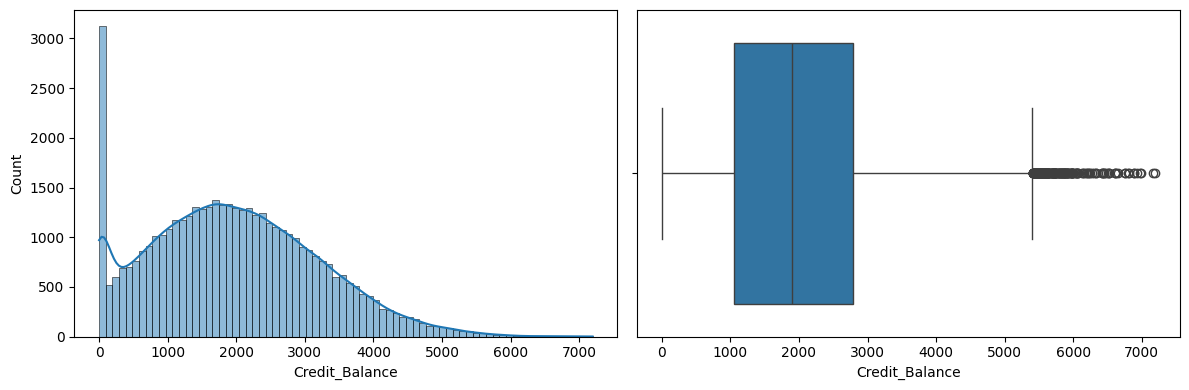

In [ ]:
# Credit_Balance
plot_numerical(X, 'Credit_Balance')

--- Đang phân tích biến: Credit_Balance ---


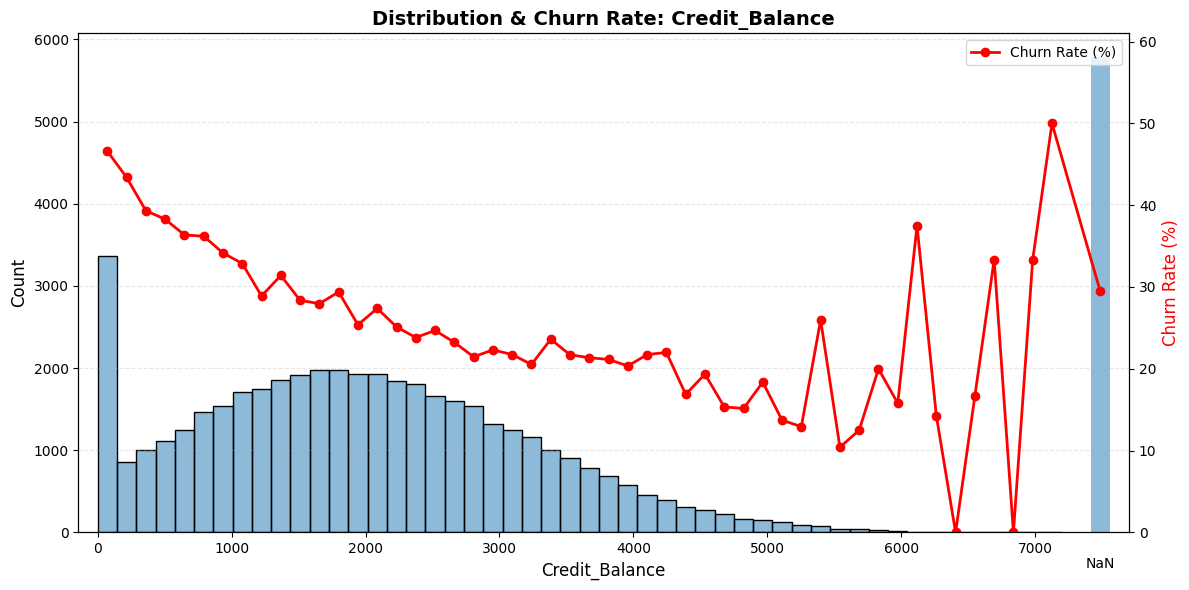

In [ ]:
plot_numerical_with_churn_rate(X, y, 'Credit_Balance')

## Phân tích biến Categorical

--- Đang phân tích biến: Gender ---
Tổng số dòng: 50000
Dữ liệu khuyết: 326 dòng (0.65%)
--------------------------------------------------


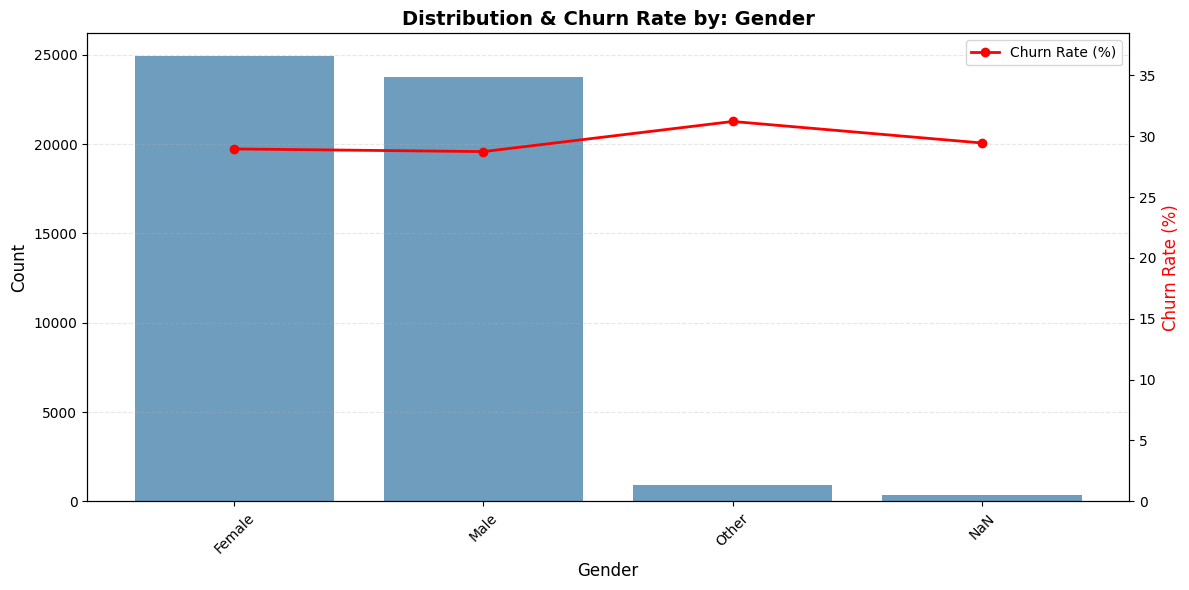

Gender  Count  % of Total  Churn_Rate
Female  24963       49.93   28.958859
  Male  23782       47.56   28.740224
 Other    929        1.86   31.216362
   NaN    326        0.65   29.447853


In [ ]:
# Gender
plot_categorical_with_churn_rate(X, y, 'Gender')

--- Đang phân tích biến: Country ---
Tổng số dòng: 50000
Dữ liệu khuyết: 326 dòng (0.65%)
--------------------------------------------------


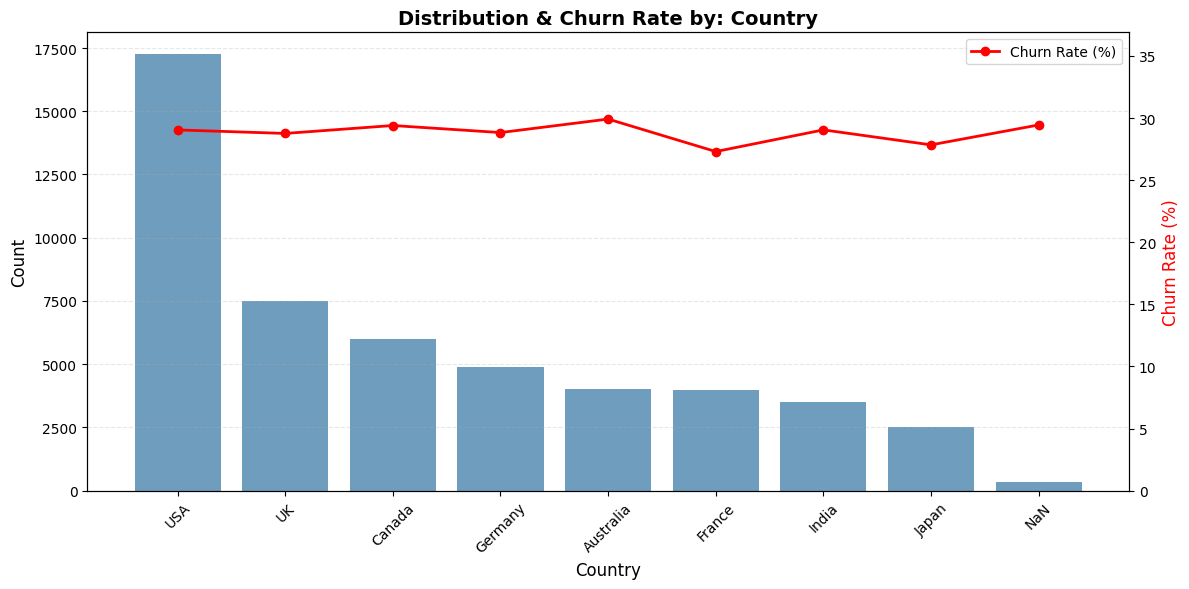

  Country  Count  % of Total  Churn_Rate
      USA  17258       34.52   29.047398
       UK   7499       15.00   28.763835
   Canada   5986       11.97   29.401938
  Germany   4897        9.79   28.833980
Australia   4034        8.07   29.920674
   France   3981        7.96   27.304697
    India   3487        6.97   29.050760
    Japan   2532        5.06   27.843602
      NaN    326        0.65   29.447853


In [ ]:
# Country
plot_categorical_with_churn_rate(X,y,  'Country')

--- Đang phân tích biến: City ---
Tổng số dòng: 50000
Dữ liệu khuyết: 326 dòng (0.65%)
--------------------------------------------------


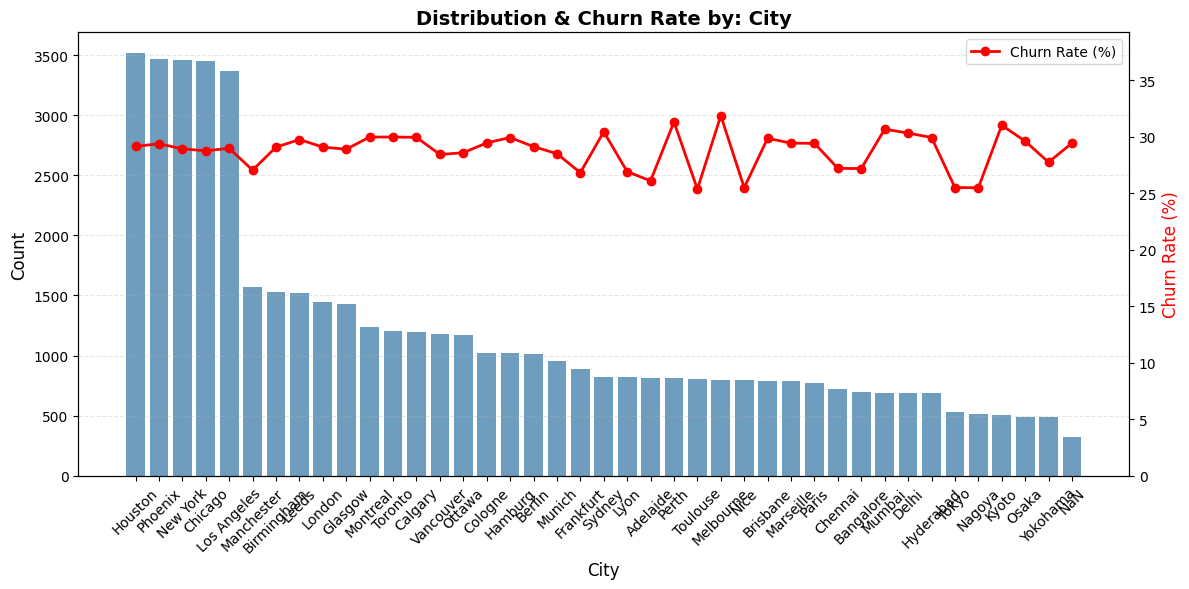

       City  Count  % of Total  Churn_Rate
    Houston   3513        7.03   29.148876
    Phoenix   3467        6.93   29.391405
   New York   3459        6.92   28.939000
    Chicago   3452        6.90   28.765933
Los Angeles   3367        6.73   28.987229
 Manchester   1571        3.14   27.052833
 Birmingham   1530        3.06   29.084967
      Leeds   1522        3.04   29.763469
     London   1447        2.89   29.094679
    Glasgow   1429        2.86   28.901330
   Montreal   1234        2.47   29.983793
    Toronto   1204        2.41   29.983389
    Calgary   1195        2.39   29.958159
  Vancouver   1178        2.36   28.438031
     Ottawa   1175        2.35   28.595745
    Cologne   1025        2.05   29.463415
    Hamburg   1022        2.04   29.941292
     Berlin   1009        2.02   29.137760
     Munich    954        1.91   28.511530
  Frankfurt    887        1.77   26.832018
     Sydney    821        1.64   30.450670
       Lyon    821        1.64   26.918392
   Adelaide

In [ ]:
# City
plot_categorical_with_churn_rate(X,y,  "City")

--- Đang phân tích biến: Signup_Quarter ---
Tổng số dòng: 50000
Dữ liệu khuyết: 326 dòng (0.65%)
--------------------------------------------------


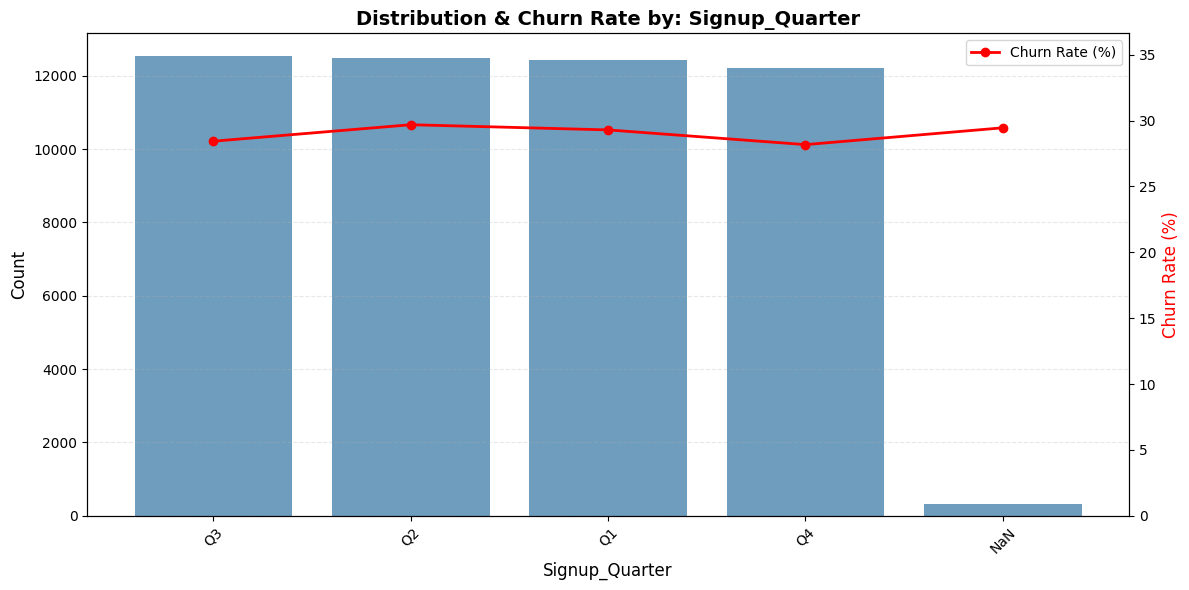

Signup_Quarter  Count  % of Total  Churn_Rate
            Q3  12532       25.06   28.431216
            Q2  12489       24.98   29.682120
            Q1  12428       24.86   29.288703
            Q4  12225       24.45   28.171779
           NaN    326        0.65   29.447853


In [ ]:
# Signup_Quarter
plot_categorical_with_churn_rate(X,y,  'Signup_Quarter')

# 2. Train/test split 80-20

In [7]:
y = y.loc[X.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Datasets list for iteration
splits = [
    ('Train', y_train),
    ('Test', y_test)
]

results = []

for name, y_split in splits:
    total = len(y_split)
    churned = (y_split == 1).sum()
    retained = (y_split == 0).sum()
    churn_rate = y_split.mean() * 100

    results.append({
        'Tập dữ liệu': name,
        'Tổng số dòng': total,
        'Ở lại (0)': retained,
        'Rời bỏ (1)': churned,
        'Tỉ lệ Churn (%)': round(churn_rate, 2)
    })

df_check_split = pd.DataFrame(results)
display(df_check_split)

,Tập dữ liệu,Tổng số dòng,Ở lại (0),Rời bỏ (1),Tỉ lệ Churn (%)
0,Train,40000,28440,11560,28.9
1,Test,10000,7110,2890,28.9


# 3. Xử lý dữ liệu khuyết

Dựa trên EDA kết hợp đối chiếu với tỷ lệ Churn trung bình (~28.8%), nhóm quyết định xử lý Missing Value theo chiến lược:

**1: Feature Engineering từ Missing Data**
* **Nhóm rủi ro cao:** Các biến `Session_Duration_Avg`, `Email_Open_Rate`, và `Customer_Service_Calls` khi bị khuyết có tỷ lệ Churn vọt lên 38% - 41% (cao hơn >10% so với mức trung bình của toàn bộ tập dữ liệu và của Median của chính biến đó). Nhóm tiến hành tạo Indicator Flag = 1 để giữ lại tín hiệu này.
* Tạo cờ `Is_Incomplete_Profile` cho những dòng bị khuyết quá 5 trường thông tin cùng lúc.

**2: Điền khuyết (Imputation)**: Đối với các biến (như `Age`, `Credit_Balance`... có tỷ lệ Churn khi khuyết ~25-30%, tương đương mức ngẫu nhiên), nhóm tiến hành điền bằng giá trị Median.

# 4. Encode biến phân loại



Dựa trên đặc điểm của từng biến, nhóm áp dụng 3 phương pháp mã hóa:

* **Nhóm 1: Biến định danh ít giá trị (`Gender`, `Country`)**
    * **Phương pháp:** One-Hot Encoding.
    * **Lý do:** Các giá trị độc lập, không có tính thứ bậc. Số lượng ít (3-8 giá trị) nên OHE không làm tăng số chiều dữ liệu quá nhiều.
* **Nhóm 2: Biến có tính thứ tự (`Signup_Quarter`)**
    * **Phương pháp:** Ordinal Encoding.
    * **Lý do:** Các giá trị (Q1, Q2, Q3, Q4) mang tính thứ tự thời gian. Việc gán giá trị (1, 2, 3, 4) giúp mô hình Tree-based dễ dàng rẽ nhánh theo các khoảng thời gian.
* **Nhóm 3: Biến định danh nhiều giá trị (`City`)**
    * **Phương pháp:** Target Encoding (Mã hóa theo tỷ lệ Churn).
    * **Lý do:** Biến có >30 giá trị, nếu dùng OHE sẽ tạo ra ma trận thưa thớt, dễ gây Overfitting. Mã hóa bằng tỷ lệ Churn trung bình của từng thành phố giúp bảo toàn tín hiệu rủi ro mà không làm tăng số cột.

- Avg_Time_Per_Page (Thời gian trung bình mỗi trang): Chỉ số này giúp mô hình nhận diện khách hàng chỉ lướt nhanh (giá trị thấp) hay đang đọc kỹ nội dung sản phẩm (giá trị cao).

- Engagement_Persona (Phân nhóm hành vi):
Phân chia khách hàng thành 4 nhóm cụ thể, sau đó Target Encoding theo tỷ lệ Churn:

    |                     | Thời gian Session (<12) | Thời gian Session (>=12) |
    |---------------------|-------------------|--------------------|
    | Số lần Login (<=2)    | Disengaged        | Occasional but Focused |
    | Số lần Login (>2)      | Frequent Window Shopper | Highly Engaged |


- Frustration_Score (Chỉ số bực bội): Tổng hợp các điểm tiêu cực của khách hàng. Giá trị càng lớn thì có nguy cơ rời bỏ càng cao.

In [8]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
import category_encoders as ce

# ==========================================
# 1. CUSTOM TRANSFORMER
# ==========================================

class MissingIndicatorCreator(BaseEstimator, TransformerMixin):
    def __init__(self, high_risk_cols, threshold=5):
        self.high_risk_cols = high_risk_cols
        self.threshold = threshold
    def fit(self, X, y=None):
        self.feature_names_in_ = X.columns.tolist()
        return self
    def transform(self, X):
        X_copy = X.copy()
        X_copy['Is_Incomplete_Profile'] = (X_copy.isna().sum(axis=1) > self.threshold).astype(int)
        for col in self.high_risk_cols:
            if col in X_copy.columns:
                X_copy[f'{col}_is_missing'] = X_copy[col].isna().astype(int)
        return X_copy
    def get_feature_names_out(self, input_features=None):
        new_features = [f'{col}_is_missing' for col in self.high_risk_cols]
        return np.array(self.feature_names_in_ + ['Is_Incomplete_Profile'] + new_features)

class AdvancedFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.feature_names_in_ = X.columns.tolist()
        return self
    def transform(self, X):
        X_copy = X.copy()
        def get_col(name):
            for c in X_copy.columns:
                if c == name or c.endswith("__" + name):
                    return X_copy[c]
            raise KeyError(f"Column {name} not found in {X_copy.columns}")
        X_copy['Avg_Time_Per_Page'] = get_col('Session_Duration_Avg') / (get_col('Pages_Per_Session') + 1e-5)
        login_freq = get_col('Login_Frequency')
        session_dur = get_col('Session_Duration_Avg')
        conditions = [
            (login_freq <= 2) & (session_dur < 12),
            (login_freq <= 2) & (session_dur >= 12),
            (login_freq > 2) & (session_dur < 12),
            (login_freq > 2) & (session_dur >= 12)
        ]
        choices = ['Disengaged', 'Occasional but Focused', 'Frequent Window Shopper', 'Highly Engaged']
        X_copy['Engagement_Persona'] = np.select(conditions, choices, default='Unknown')
        X_copy['Frustration_Score'] = (get_col('Cart_Abandonment_Rate') + get_col('Returns_Rate') + (get_col('Customer_Service_Calls') * 10))
        return X_copy
    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_in_ + ['Avg_Time_Per_Page', 'Engagement_Persona', 'Frustration_Score'])

# ==========================================
# 2. THIẾT LẬP CÁC BƯỚC PIPELINE
# ==========================================
high_risk_missing = ['Session_Duration_Avg', 'Email_Open_Rate', 'Customer_Service_Calls']
cat_cols = ['Gender', 'Country', 'City', 'Signup_Quarter']
num_cols = [col for col in X_train.columns if col not in cat_cols]


zero_impute_cols = ['Customer_Service_Calls', 'Cart_Abandonment_Rate']
median_impute_cols = [col for col in num_cols if col not in zero_impute_cols]

imputation_station = ColumnTransformer(
    transformers=[
        # Nhóm 1: Điền bằng 0 cho các biến hành vi tích lũy
        ('zero_imputer', SimpleImputer(strategy='constant', fill_value=0), zero_impute_cols),

        # Nhóm 2: Điền trung vị cho các biến chỉ số (Age, Tenure, v.v.)
        ('median_imputer', SimpleImputer(strategy='median'), median_impute_cols)
    ],
    remainder='passthrough'
).set_output(transform="pandas")


encoding_station = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), ['remainder__Gender', 'remainder__Country']),
        ('ordinal', OrdinalEncoder(categories=[['Q1', 'Q2', 'Q3', 'Q4']]), ['remainder__Signup_Quarter']),
        ('target_enc', ce.TargetEncoder(), ['remainder__City', 'Engagement_Persona'])
    ],
    remainder='passthrough'
).set_output(transform="pandas")

preprocessor = Pipeline(steps=[
    ('missing_flag_creator', MissingIndicatorCreator(high_risk_cols=high_risk_missing, threshold=5)),
    ('missing_imputer', imputation_station),
    ('feature_engineer', AdvancedFeatureEngineer()),
    ('encoder', encoding_station)
])

In [12]:
preprocessor.fit(X_train, y_train)

eda_pipeline = preprocessor[:-1]

X_train_eda = eda_pipeline.transform(X_train)

--- Đang phân tích biến: Engagement_Persona ---
Tổng số dòng: 40000
Dữ liệu khuyết: 0 dòng (0.00%)
--------------------------------------------------


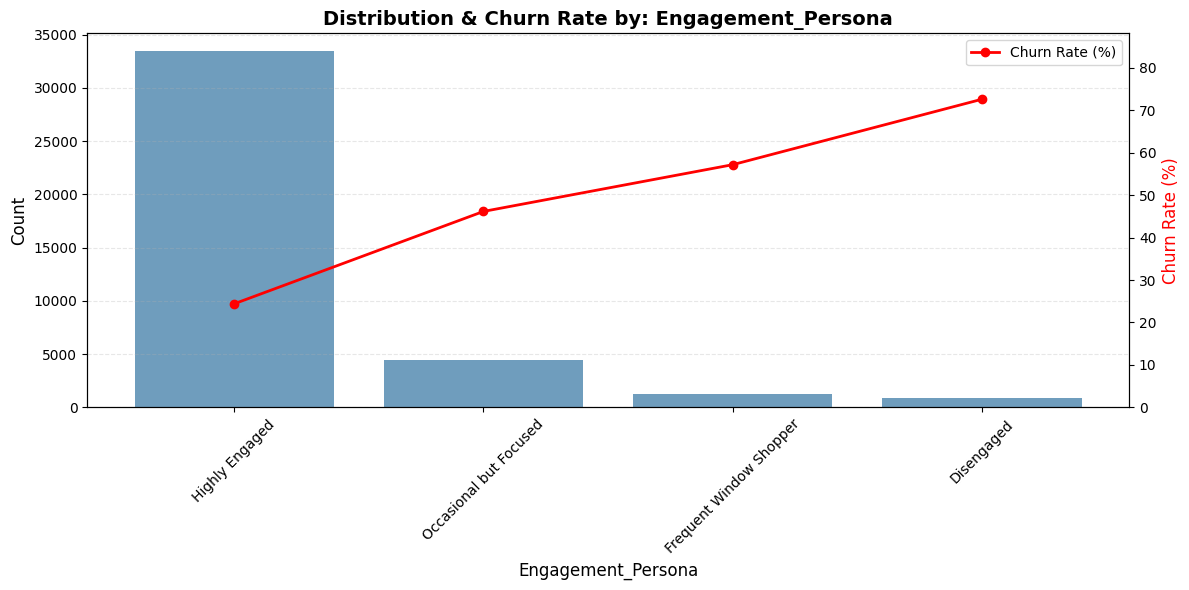

     Engagement_Persona  Count  % of Total  Churn_Rate
         Highly Engaged  33438       83.60   24.400383
 Occasional but Focused   4425       11.06   46.146893
Frequent Window Shopper   1244        3.11   57.154341
             Disengaged    893        2.23   72.564390


In [13]:
plot_categorical_with_churn_rate(X_train_eda, y_train, 'Engagement_Persona')

--- Đang phân tích biến: Frustration_Score ---


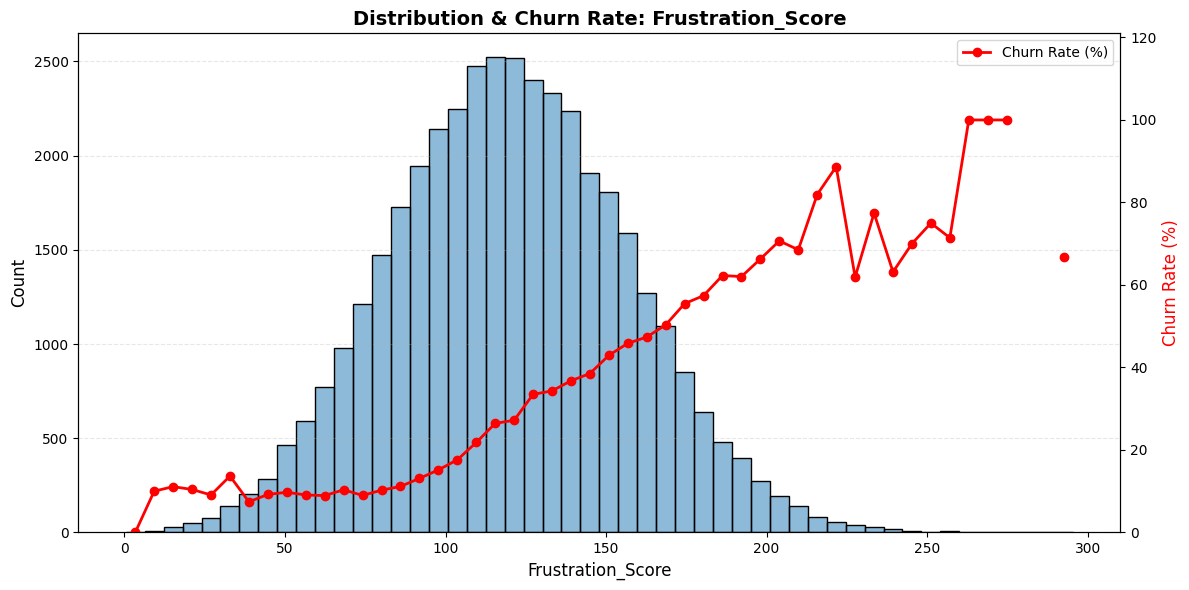

In [ ]:
plot_numerical_with_churn_rate(X_train_eda, y_train, 'Frustration_Score')

In [14]:
preprocessor.fit(X_train, y_train)

X_train_final = preprocessor.transform(X_train)
X_test_final  = preprocessor.transform(X_test)

print(f"Số lượng Feature gốc: {X_train.shape[1]}")
print(f"Số lượng Feature sau khi tiền xử lý: {X_train_final.shape[1]}")

Số lượng Feature gốc: 24
Số lượng Feature sau khi tiền xử lý: 38


# 5. Tỷ lệ mất cân bằng

In [15]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(ratio)

weight_dict = {0: 1.0, 1: ratio}

2.4602076124567476


# 6. Thiết lập Pipeline và Grid Search để tìm tham số tối ưu (theo Recall)

**Lưu ý:** Các cell bên dưới dùng để tìm tham số tối ưu có thời gian chạy khá lâu. Nếu chỉ muốn sử dụng mô hình cuối cùng với tham số đã chọn, chuyển sang **Phần 7**.

In [16]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('scaler', 'passthrough'),
    ('classifier', LogisticRegression())
])

In [17]:
param_grid_lr = [
    {
        'scaler': [StandardScaler(), MinMaxScaler(feature_range=(0, 1))],
        'classifier': [LogisticRegression(max_iter=2000, random_state=42)],

        'classifier__penalty': ['l1'],
        'classifier__solver': ['liblinear', 'saga'],
        'classifier__class_weight': ['balanced', weight_dict],
        'classifier__C': [0.1, 1.0, 10.0]
    }
]

In [18]:
param_grid_rf = [
    {
        'scaler': ['passthrough'],
        'classifier': [RandomForestClassifier(random_state=42)],

        'classifier__class_weight': ['balanced', weight_dict],

        'classifier__n_estimators': [100, 200, 300],

        'classifier__max_depth': [10, 20, 30, None],

        'classifier__min_samples_split': [2, 5, 10],

        'classifier__min_samples_leaf': [1, 2, 4],

        'classifier__max_features': ['sqrt', 'log2']
    }
]

In [19]:
param_grid_xgb = [
    {
        'scaler': ['passthrough'],
        'classifier': [XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')],

        'classifier__n_estimators': [100, 200, 500],
        'classifier__learning_rate': [0.01, 0.05, 0.1],

        'classifier__max_depth': [3, 5, 7],
        'classifier__min_child_weight': [1, 5, 10],

        'classifier__subsample': [0.8, 1.0],
        'classifier__colsample_bytree': [0.8, 1.0],

        'classifier__scale_pos_weight': [1, 1.5, ratio]
    }
]

In [ ]:
from sklearn.model_selection import learning_curve

# 1. Hàm vẽ Đường cong học tập (Learning Curve)
def plot_learning_curve(estimator, X, y, title):
    plt.figure(figsize=(12, 8))
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=3, scoring='recall', n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5)
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.plot(train_sizes, train_mean, 'o-', color="r", label="Train")
    plt.plot(train_sizes, test_mean, 'o-', color="g", label="Validation")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

    plt.title(f'Learning Curve: {title}', fontsize=14, fontweight='bold')
    plt.xlabel('Số lượng mẫu huấn luyện', fontsize=12)
    plt.ylabel('Recall', fontsize=12)
    plt.legend(loc="best")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# 2. Hàm vẽ Feature Importance Random Forest
def plot_rf_feature_importance(best_rf_pipeline, feature_names):
    classifier = best_rf_pipeline.named_steps['classifier']
    importances = classifier.feature_importances_
    indices = np.argsort(importances)[-10:]

    plt.figure(figsize=(12, 8))
    plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.title('Top Feature Importances', fontsize=14, fontweight='bold')
    plt.xlabel('Mức độ quan trọng', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# 3. Hàm vẽ Feature Importance XGB
def plot_xgb_feature_importance(best_pipeline, feature_names):
    classifier = best_pipeline.named_steps['classifier']
    importances = classifier.feature_importances_
    indices = np.argsort(importances)[-15:]
    plt.figure(figsize=(12, 8))
    plt.barh(range(len(indices)), importances[indices], color='orange', align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.title('Top Feature Importances', fontsize=14, fontweight='bold')
    plt.show()

## Logistic Regression

In [ ]:
print("="*50)
print("ĐANG CHẠY LOGISTIC REGRESSION")
print("="*50)

grid_lr = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid_lr,
    cv=3,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train, y_train)
best_lr = grid_lr.best_estimator_

y_pred_lr = best_lr.predict(X_test)
y_pred_proba_lr = best_lr.predict_proba(X_test)[:, 1]

print(f"\nCấu hình tốt nhất tìm được: {grid_lr.best_params_}")
print(f"ROC AUC Score (Cross-Validation): {grid_lr.best_score_:.4f}")

ĐANG CHẠY LOGISTIC REGRESSION
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Cấu hình tốt nhất tìm được: {'classifier': LogisticRegression(max_iter=2000, random_state=42), 'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear', 'scaler': StandardScaler()}
ROC AUC Score (Cross-Validation): 0.7235


In [ ]:
print("\nKẾT QUẢ LOGISTIC REGRESSION:")
print(f"ROC AUC Score (Test): {roc_auc_score(y_test, y_pred_proba_lr):.4f}")
print("-" * 50)
print(classification_report(y_test, y_pred_lr))


KẾT QUẢ LOGISTIC REGRESSION:
ROC AUC Score (Test): 0.8028
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.87      0.73      0.79      7064
           1       0.52      0.73      0.61      2871

    accuracy                           0.73      9935
   macro avg       0.70      0.73      0.70      9935
weighted avg       0.77      0.73      0.74      9935



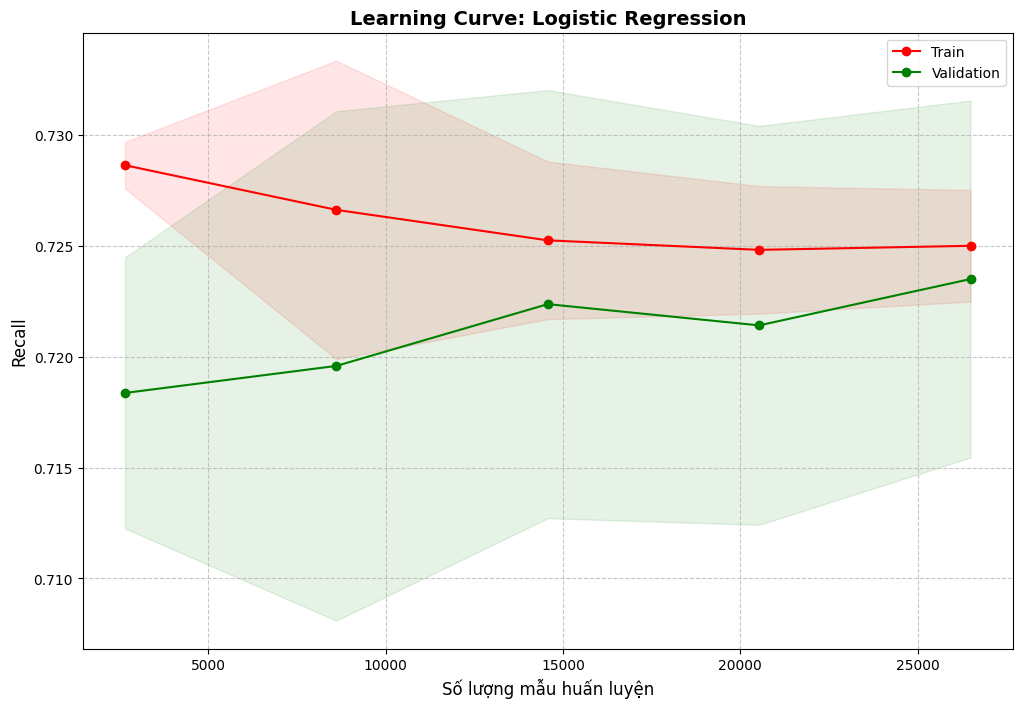

In [ ]:
# Trực quan hóa
plot_learning_curve(best_lr, X_train, y_train, "Logistic Regression")

## Random Forest

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

print("\n" + "="*50)
print("ĐANG CHẠY RANDOM FOREST")
print("="*50)

random_rf = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid_rf,
    cv=3,
    n_iter=15,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

random_rf.fit(X_train, y_train)
best_rf = random_rf.best_estimator_

print(f"\nCấu hình tốt nhất tìm được: {random_rf.best_params_}")
print(f"\nROC AUC Score (Cross-Validation): {random_rf.best_score_:.4f}")


ĐANG CHẠY RANDOM FOREST
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Cấu hình tốt nhất tìm được: {'scaler': 'passthrough', 'classifier__n_estimators': 200, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'log2', 'classifier__max_depth': 10, 'classifier__class_weight': 'balanced', 'classifier': RandomForestClassifier(random_state=42)}

ROC AUC Score (Cross-Validation): 0.8348


In [ ]:
y_pred_rf = best_rf.predict(X_test)
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]

print("\nKẾT QUẢ RANDOM FOREST:")
print(f"ROC AUC Score (Test): {roc_auc_score(y_test, y_pred_proba_rf):.4f}")
print("-" * 50)
print(classification_report(y_test, y_pred_rf))


KẾT QUẢ RANDOM FOREST:
ROC AUC Score (Test): 0.9205
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      7064
           1       0.82      0.85      0.83      2871

    accuracy                           0.90      9935
   macro avg       0.88      0.89      0.88      9935
weighted avg       0.90      0.90      0.90      9935



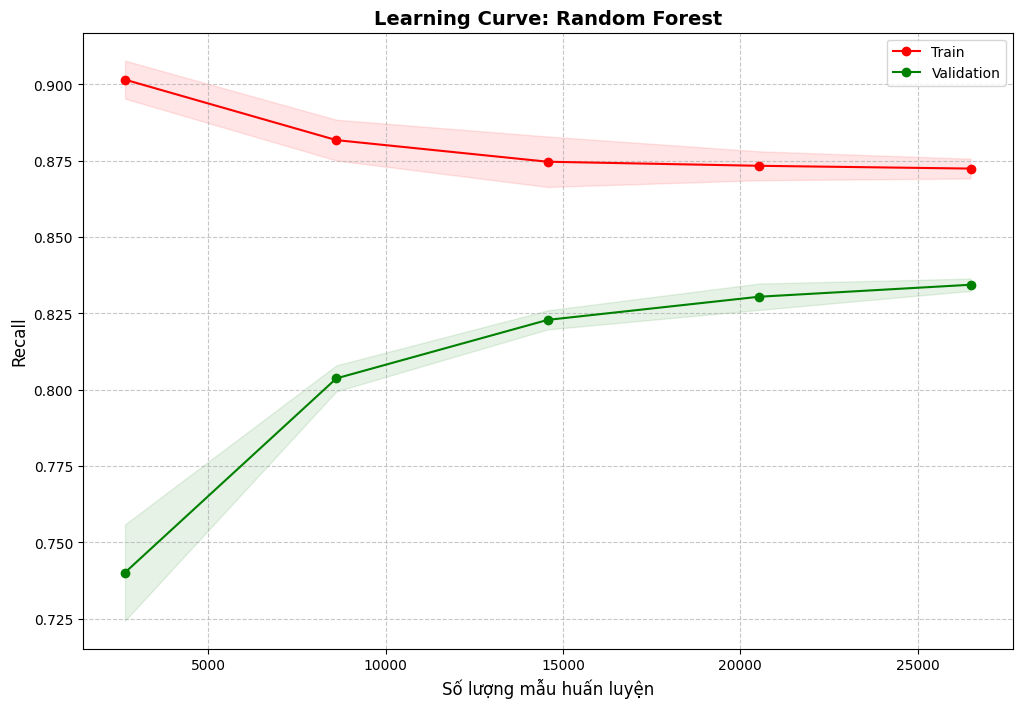

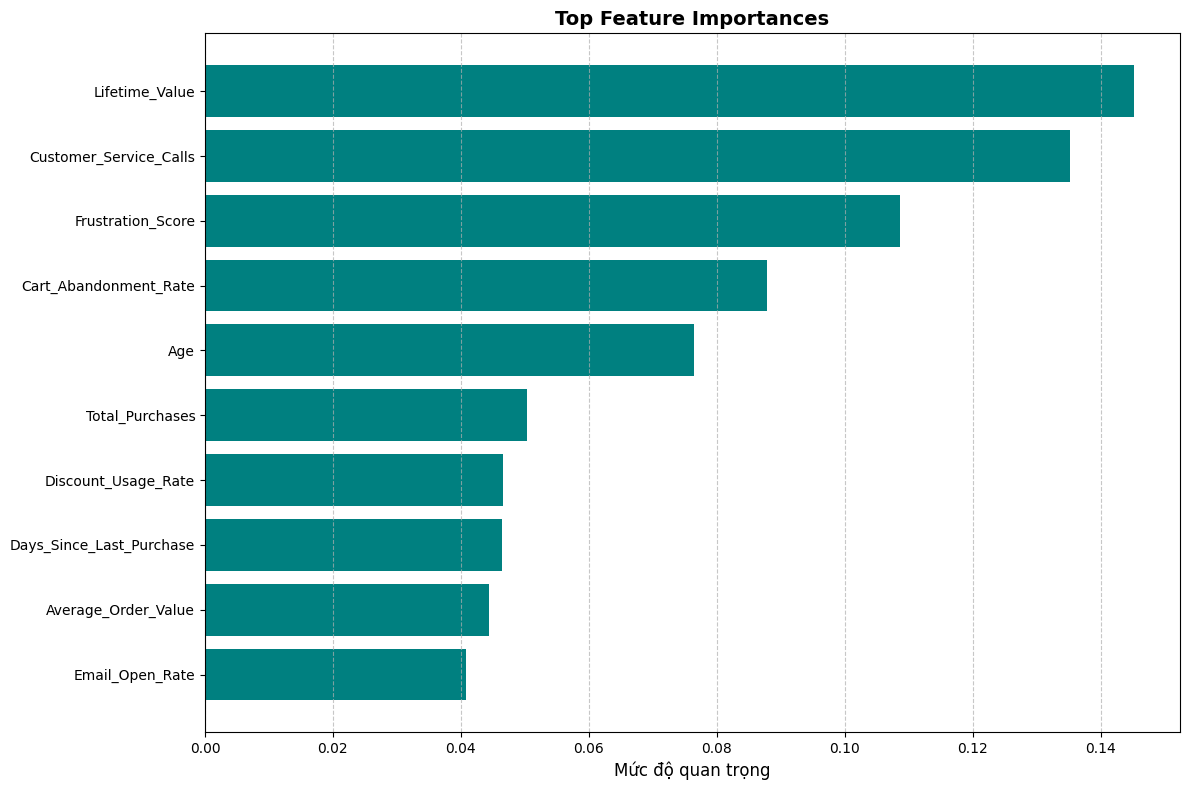

In [ ]:
# Trực quan hóa
plot_learning_curve(best_rf, X_train, y_train, "Random Forest")

feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()
feature_names = [name.split('__')[-1] for name in feature_names]

plot_rf_feature_importance(best_rf, feature_names)

## XGBoost

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

print("\n" + "="*50)
print("ĐANG CHẠY XGBOOST")
print("="*50)

random_xgb = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid_xgb,
    n_iter=15,
    cv=3,
    scoring='recall',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_xgb.fit(X_train, y_train)

best_xgb = random_xgb.best_estimator_

print(f"\nCấu hình tốt nhất tìm được: {random_xgb.best_params_}")
print(f"ROC AUC Score (Cross-Validation): {random_xgb.best_score_:.4f}")




ĐANG CHẠY XGBOOST
Fitting 3 folds for each of 15 candidates, totalling 45 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:42:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Cấu hình tốt nhất tìm được: {'scaler': 'passthrough', 'classifier__subsample': 0.8, 'classifier__scale_pos_weight': np.float64(2.4606810067055647), 'classifier__n_estimators': 500, 'classifier__min_child_weight': 1, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.01, 'classifier__colsample_bytree': 0.8, 'classifier': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,

In [ ]:
# Dự báo tập Test
y_pred_xgb = best_xgb.predict(X_test)
y_pred_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

print("\nKẾT QUẢ XGBOOST:")
print(f"ROC AUC Score (Test): {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")
print("-" * 50)
print(classification_report(y_test, y_pred_xgb))


KẾT QUẢ XGBOOST:
ROC AUC Score (Test): 0.9278
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.93      0.94      7064
           1       0.83      0.86      0.85      2871

    accuracy                           0.91      9935
   macro avg       0.89      0.89      0.89      9935
weighted avg       0.91      0.91      0.91      9935



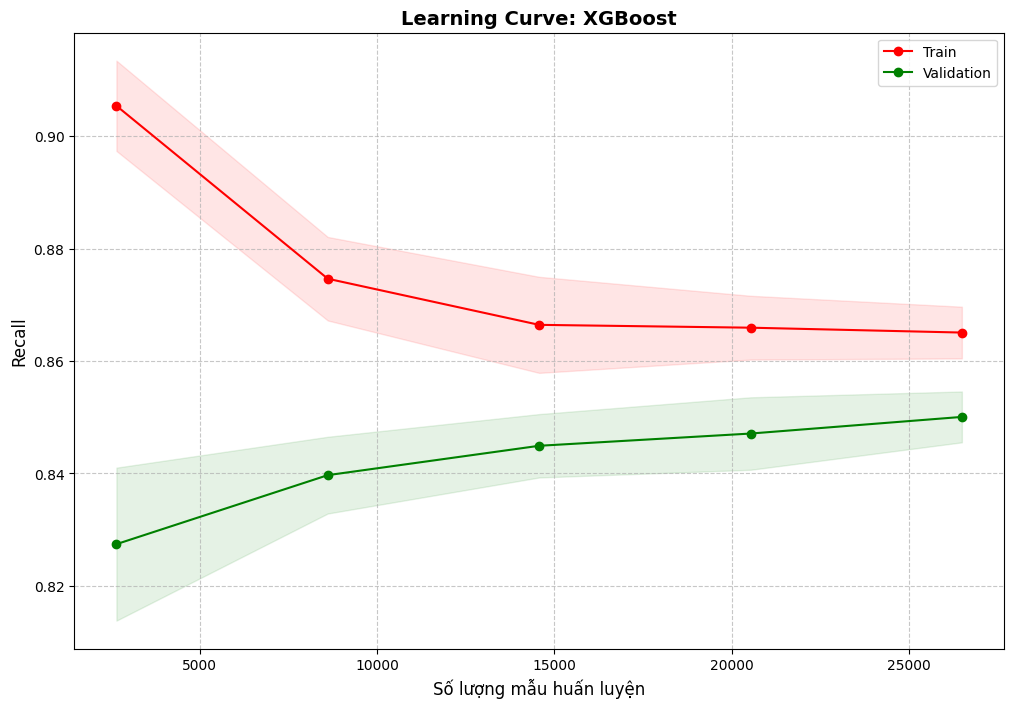

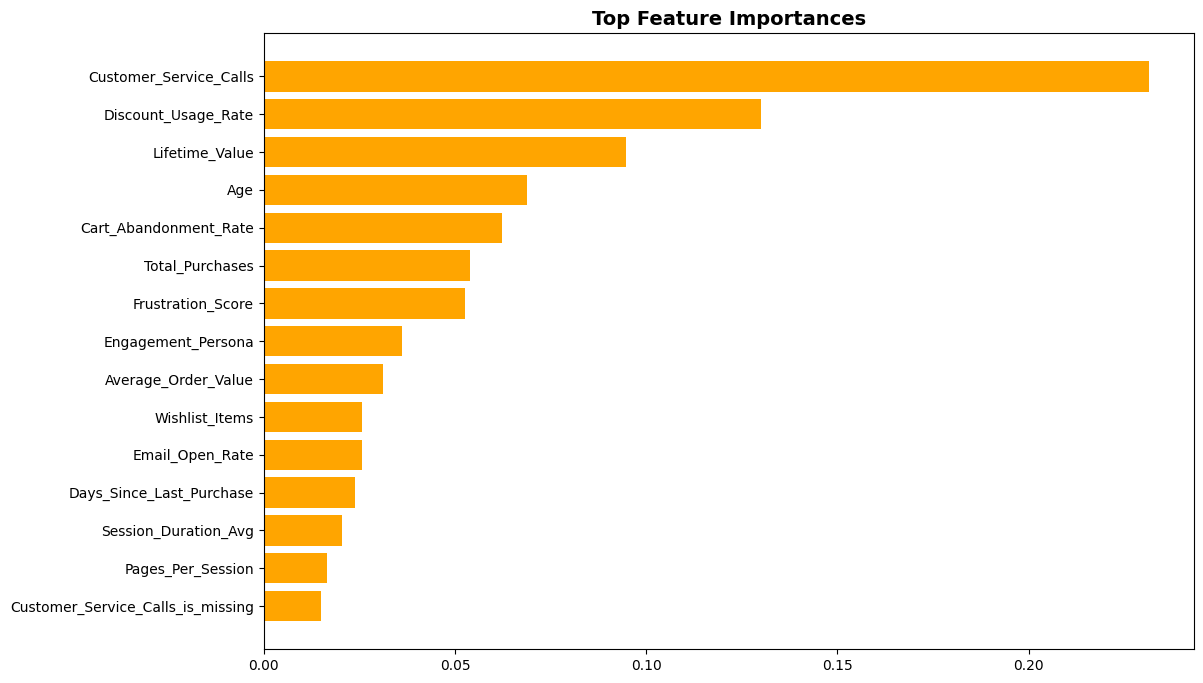

In [ ]:
# Trực quan hóa
plot_learning_curve(best_xgb, X_train, y_train, "XGBoost")

# Lấy feature names từ preprocessor
feature_names = best_xgb.named_steps['preprocessor'].get_feature_names_out()

feature_names = [name.split('__')[-1] for name in feature_names]

plot_xgb_feature_importance(best_xgb, feature_names)

# 7. Mô hình XGBoost cuối cùng

Mô hình XGBoost được khởi tạo với bộ tham số tối ưu và đưa vào pipeline cùng bước tiền xử lý. Sau đó huấn luyện trên tập `X_train`, `y_train`.

Sau khi dự đoán xác suất, mô hình sử dụng **threshold = 0.45** nhằm:
- Tăng Recall (bắt được nhiều khách rời bỏ hơn)
- Nhưng vẫn giữ Precision khoảng 0.8
Đây là điểm cân bằng tốt giữa bắt đúng Churn và hạn chế cảnh báo sai


ĐANG HUẤN LUYỆN MÔ HÌNH XGBOOST CUỐI CÙNG...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:26:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


ROC AUC Score (Test) : 0.9285
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.91      0.92      7110
           1       0.79      0.87      0.83      2890

    accuracy                           0.90     10000
   macro avg       0.87      0.89      0.88     10000
weighted avg       0.90      0.90      0.90     10000



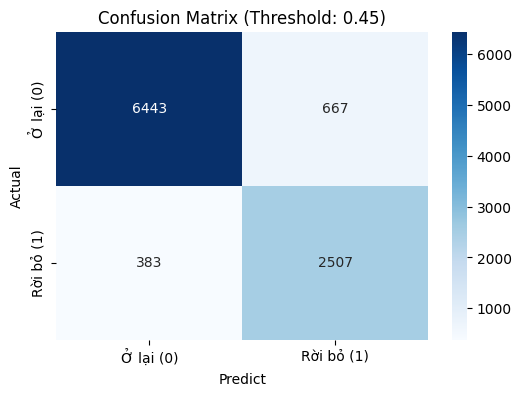

In [20]:
print("ĐANG HUẤN LUYỆN MÔ HÌNH XGBOOST CUỐI CÙNG...")

final_xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=5,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', final_xgb)
])

final_pipeline.fit(X_train, y_train)


FINAL_THRESHOLD = 0.45

y_test_probs = final_pipeline.predict_proba(X_test)[:, 1]

y_pred_final = (y_test_probs >= FINAL_THRESHOLD).astype(int)


print(f"ROC AUC Score (Test) : {roc_auc_score(y_test, y_test_probs):.4f}")
print("-" * 60)
print(classification_report(y_test, y_pred_final))

cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ở lại (0)', 'Rời bỏ (1)'],
            yticklabels=['Ở lại (0)', 'Rời bỏ (1)'])
plt.title(f"Confusion Matrix (Threshold: {FINAL_THRESHOLD})")
plt.ylabel('Actual')
plt.xlabel('Predict')
plt.show()

# 8. Kết luận


Trong bài tập lớn này, nhóm đã xây dựng thành công hệ thống dự đoán khách hàng rời bỏ (Customer Churn Prediction) với pipeline xử lý dữ liệu và mô hình học máy tối ưu.

### Feature Engineering
Nhóm không chỉ sử dụng dữ liệu thô mà còn đề xuất các đặc trưng mang ý nghĩa:

- **Frustration_Score**
- **Engagement_Persona**
- **Avg_Time_Per_Page**

Ngoài ra, **Missing Values** được tùy chỉnh riêng cho các biến rủi ro cao nhằm tránh làm mất tín hiệu quan trọng.

### Model Selection
Sau quá trình thử nghiệm và tuning, mô hình **XGBoost** cho kết quả tốt nhất nhờ:

- Khả năng xử lý dữ liệu mất cân bằng với `scale_pos_weight = 2.46`
- Khả năng học tương tác phi tuyến mạnh

Mô hình đạt **ROC AUC = 0.85**, cho thấy khả năng phân biệt tốt giữa khách hàng rời bỏ và ở lại.

### Threshold Tuning
Thay vì sử dụng ngưỡng mặc định `0.5`, nhóm điều chỉnh **threshold = 0.45** dựa trên đường cong Precision-Recall:

- Tăng Recall → bắt được nhiều khách có nguy cơ rời bỏ hơn  
- Precision vẫn giữ khoảng **0.8**  
- Phù hợp với mục tiêu kinh doanh: hạn chế bỏ sót churn  

---

## Business Insights

Phân tích Feature Importance cho thấy 3 nguyên nhân chính dẫn đến churn:

### Chất lượng dịch vụ là yếu tố quan trọng nhất:
Các biến có ảnh hưởng lớn nhất:

- `Customer_Service_Calls`
- `Frustration_Score`

Khách hàng rời bỏ thường là kết quả của quá trình tích tụ sự thất vọng khi vấn đề không được xử lý hiệu quả.

### Khuyến mãi:
Khách hàng có `Discount_Usage_Rate` cao có xu hướng rời bỏ nhanh.  
Đây là nhóm nhạy cảm với giá và dễ chuyển sang đối thủ khi hết ưu đãi.


---
## Hướng phát triển tương lai

### Cải thiện Feature Engineering & Tiền xử lý dữ liệu
Có thể tiếp tục nghiên cứu và áp dụng các phương pháp Feature Engineering nâng cao:

- Tạo thêm các đặc trưng hành vi theo thời gian (time-based features)  
- Khai thác interaction giữa nhiều biến thay vì chỉ 2 biến  
- Thử nghiệm các chiến lược xử lý missing và outlier hiệu quả hơn  

Bên cạnh đó, nhóm có thể cải thiện pipeline tiền xử lý:

- Chuẩn hóa dữ liệu tốt hơn  
- Xử lý nhiễu (noise) và dữ liệu bất thường  
- Tối ưu hóa quy trình feature selection  

### Kết hợp đa dạng nguồn dữ liệu
Mở rộng dataset để mô hình học được nhiều tín hiệu:

- Dữ liệu hành vi theo thời gian thực (real-time tracking)  
- Dữ liệu giao dịch chi tiết  
- Dữ liệu marketing (email, campaign response)  
- Dữ liệu từ nhiều kênh (web, app, CSKH)  

### Bổ sung dữ liệu văn bản (Text Data)
Thu thập thêm:

- Bình luận khách hàng  
- Review sản phẩm  
- Nội dung chat CSKH  

Áp dụng:

- NLP (Xử lý ngôn ngữ tự nhiên)  
- Sentiment Analysis (phân tích cảm xúc)  

→ Giúp mô hình hiểu sâu hơn về trải nghiệm và cảm xúc khách hàng, từ đó cải thiện khả năng dự đoán churn.